# Notebook for PlatoSim3 paper (2022)

This notebook is used to generate all input plots shown in the PlatoSim3 paper; Jannsen et al. (2022).
Sources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

In [2]:
import os
import h5py
import scipy
import wotan
import numpy as np
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

import transitleastsquares as tls

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.validation import switchOffAllEffects
from platosim.matplotlibrc import setup_paper
setup_paper()

# Constants
day = 86400

---
## PLATO LOPS1
---

In [ ]:
# Plot overall figure
fig = pt.plotPlatoFOV('SPF', fs=20, system='icrs')

# Plot N-CAM visibility
box1 = fig.text(0.250, 0.655, '6',  fontsize=20)
box2 = fig.text(0.335, 0.637, '12', fontsize=20)
box3 = fig.text(0.400, 0.625, '18', fontsize=20)
box4 = fig.text(0.510, 0.605, '24', fontsize=20)

# Plot white boxes below
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
plt.show()

# Save figure
fig.savefig('PlatoFOV.png', bbox_inches='tight', dpi=200)

---
## Spectral Response curve
---

In [ ]:
grid_no = 1000
path = os.getenv("PLATO_PROJECT_HOME") + "/python/platosim/varsim/data"

# Import PLATO passband
wvl_plato = np.loadtxt(f"{path}/response_plato.txt")[:,0]  # [nm]                                                                                                                
tra_plato = np.loadtxt(f"{path}/response_plato.txt")[:,1]  # Absolute
# Normalize passband
tra_plato /= tra_plato.max()
wvl_int_plato  = np.linspace(wvl_plato[0], wvl_plato[-1], grid_no)                                                                                                                                         
passband_plato = scipy.interpolate.make_interp_spline(wvl_plato, tra_plato, k=3)                                                                                                                                             
tran_int_plato = passband_plato(wvl_int_plato)

# Import TESS passband
wvl_tess = np.loadtxt(f"{path}/response_tess.txt")[:,0]                                                                                                                
tra_tess = np.loadtxt(f"{path}/response_tess.txt")[:,1]                                                                                                              
wvl_int_tess  = np.linspace(wvl_tess[0], wvl_tess[-1], grid_no)                                                                                                                                         
passband_tess = scipy.interpolate.make_interp_spline(wvl_tess, tra_tess, k=3)                                                                                                                                             
tran_int_tess = passband_tess(wvl_int_tess)                                                                                                                                                             
 
# Import Kepler passband                                                                                                                                                                                                                                                                                                                                                                                          
wvl_kepler  = np.loadtxt(f"{path}/response_kepler.txt")[:,0]                                                                                                                  
tran_kepler = np.loadtxt(f"{path}/response_kepler.txt")[:,1]                                                                                                                      
wvl_int_kepler  = np.linspace(wvl_kepler[0], wvl_kepler[-1], grid_no)                                                                                                                                   
passband_kepler = scipy.interpolate.make_interp_spline(wvl_kepler, tran_kepler, k=3)                                                                                                                                      
tran_int_kepler = passband_kepler(wvl_int_kepler) 

In [ ]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(wvl_plato,  tra_plato, 'ro') 
ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(400, 1100)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

# Save figure
fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

---
## Sky background
---

In [ ]:
# First make a grid in Equatorial coordinates
N = 120
x = np.linspace(0, 360, N)
y = np.linspace(-90, 90, N)
x, y = np.meshgrid(x, y)
RA  = x.flatten() * u.degree
Dec = y.flatten() * u.degree

c = SkyCoord(ra=RA, dec=Dec, frame='icrs')
ra_rad = c.ra.wrap_at(180 * u.deg).radian
dec_rad = c.dec.radian
RA, Dec = RA.value, Dec.value

plt.figure(figsize=(8,4.2))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Equatorial", pad=25)
plt.grid(True)
plt.plot(ra_rad, dec_rad, 'o', markersize=1)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [ ]:
# Compared to the Galactic coordinate system
eli = c.geocentricmeanecliptic
l = -eli.lon.wrap_at("180d").radian
b = eli.lat.radian

plt.figure(figsize=(9,5))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Ecliptic", pad=25)
plt.grid(True)
plt.scatter(l, b, s=2)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [ ]:
# Compared to the Galactic coordinate system
gal = c.galactic
l = -gal.l.wrap_at("180d").radian
b = gal.b.radian

plt.figure(figsize=(9,5))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Galactic", pad=25)
plt.grid(True)
plt.scatter(l, b, s=2)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [ ]:
# # Compute the sky background for each grid point (as pointing) using PlatoSim
# N = len(RA.value)
# sky = np.zeros(N)

# for i, ra, dec in zip(range(N), RA.value, Dec.value):
    
#     print(i)
#     sim = Simulation("output_skybackground", outputDir=os.getcwd())
#     switchOffAllEffects(sim)
    
#     # One full-frame exposure
#     sim["ObservingParameters/NumExposures"] = 1
#     sim["ObservingParameters/RApointing"]   = ra
#     sim["ObservingParameters/DecPointing"]  = dec
#     sim["Sky/SkyBackground"]   = -1
#     sim["SubField/NumRows"]    = 1
#     sim["SubField/NumColumns"] = 1
    
#     # Define catalogue
#     if i == 0:
#         row = np.array([0])
#         col = np.array([0])
#         mag = np.array([30])
#         ID  = [0]
#         starcatFile = os.getcwd() + "/starcat.txt"
#     sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
    
#     # Set subfield to same location as platform pointing
#     sim.setSubfieldAroundCoordinates(ra, dec, 1, 1, normal=True)
    
#     # Simulate each sky background
#     simfile = sim.run(removeOutputFile = True)
#     sky[i] = simfile.getImage(0)

In [ ]:
data = np.loadtxt(f"{os.getcwd()}/sky0.txt")
RA, Dec, sky = data[:,0], data[:,1], data[:,2]
# np.savetxt(os.getcwd() + "/sky0.txt", np.transpose([RA.value, Dec.value, sky]))
Dec *= -1
for i in range(len(RA)):
    if Dec[i] >= 0:
        RA[i] -= 5.8
    else:
        RA[i] += 5.8

In [ ]:
# Add the sky projection ontop as transparent layer
fig, ax = plt.subplots(figsize=(10,5))
axes = fig.add_subplot(111, projection='aitoff', facecolor='none')

# Bases
lon = np.deg2rad(np.linspace(-102, 258, 100)) # -102, 258, 100)
lat = np.zeros_like(lon)
ecli = SkyCoord(frame="geocentricmeanecliptic", lon=lon, lat=lat, unit=u.radian)
equa = SkyCoord(RA, Dec, frame='icrs', unit=u.deg)

# Equatorial
# x = -equa.ra.wrap_at('180d').radian
# y = equa.dec.radian
# equa_line = ecli.transform_to("icrs")
# x_line = -equa_line.ra.wrap_at('180d').radian
# y_line = equa_line.dec.radian
# plt.plot(x_line, y_line, "--", c="royalblue", lw=2, zorder=1)
# axes.set_xlabel(r'RA, $\alpha$ [deg]')
# axes.set_ylabel(r'Dec, $\delta$ [deg]')

# Ecliptic
grid = equa.geocentricmeanecliptic #barycentricmeanecliptic
x = -grid.lon.wrap_at('180d').radian
y = grid.lat.radian
axes.set_xlabel(r'Longitude, $\lambda$ [$^{\circ}$]')
axes.set_ylabel(r'Latitude, $\beta$ [$^{\circ}$]')

# Galactic
# grid = equa.galactic
# x = -grid.l.wrap_at('180d').radian
# y = grid.b.radian
# line = ecli.galactic
# x_line = -line.l.wrap_at('180d').radiesan
# y_line = line.b.radian
# plt.plot(x_line, y_line, "--", c="royalblue", lw=2, zorder=-1)
# axes.set_xlabel(r'Longitude, $l$ [deg]')
# axes.set_ylabel(r'Latitude, $b$ [deg]')

# Plot Aitoff projection in Galactic coordinates
fs, ms = 20, 100

# Plot the targets on the sky (autumn_r, rainbow)
im = plt.scatter(x, y, c=sky, s=ms, cmap="cubehelix", norm=colors.LogNorm(), zorder=-1)

# Vertical or horizontal colorbar showing magnitudes
cbarax = fig.add_axes([0.25, -0.05, 0.52, 0.03])
sky_min = sorted(sky)[1]
sky_max = np.max(sky)
cbar = plt.colorbar(im, orientation='horizontal', cax=cbarax, extend='both')
cbar.set_label(r'Sky background flux, $F_{\rm sky}$ [$\gamma \ s^{-1} \ \rm pixel^{-1}$]', fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Change the tick labels so that they are 0->360, rather than -180->+180
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
# tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)

# Change y ticks and remove last to make space for title
tickLabels = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75])
axes.set_yticklabels(tickLabels)

# Plot ticks on top of data 
axes.tick_params(axis='both', which='major', labelsize=15, zorder=1)
axes.tick_params(axis='x', colors='w')

# Increase x and y tick labels
axes.xaxis.set_tick_params(labelsize=fs+1)
axes.yaxis.set_tick_params(labelsize=fs)

# Add axes labels
axes.xaxis.set_label_coords(0.52, -0.025)

# Set grid and remore outer ticks (if set by default)
axes.grid(True, alpha=0.3)
ax.axis('off')
plt.draw()
# plt.tight_layout()

# Save figure
fig.savefig('skybackground.png', bbox_inches='tight', dpi=200)

---
## Jitter comparison: Prime vs. Red noise
---

In [6]:
# Load Prime
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])

# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


In [7]:
# Load simulated PlatoSim red noise jitter
f = h5py.File(f"{os.getcwd()}/redNoiseJitter8Hz.hdf5", "r")
x = f['ACS/Yaw'][:]

In [8]:
# Compute PSD for Prime data
f_prime, psd_prime = periodogram(df["x"], 8, scaling='density')
f_prime   *= 1e6  # [muHz]
psd_prime *= 1e6  # [ppm^2/muHz]

# Compute PSF for PlatoSim red noise
f_red, psd_red = periodogram(x, 8, scaling='density')
f_red   *= 1e6  # [muHz]
psd_red *= 1e6  # [ppm^2/muHz]

# Median filters of 1 min
n = int(60 / 0.125)
psd_prime_med = scipy.ndimage.median_filter(psd_prime, n)
psd_red_med   = scipy.ndimage.median_filter(psd_red,   n)

<IPython.core.display.Javascript object>


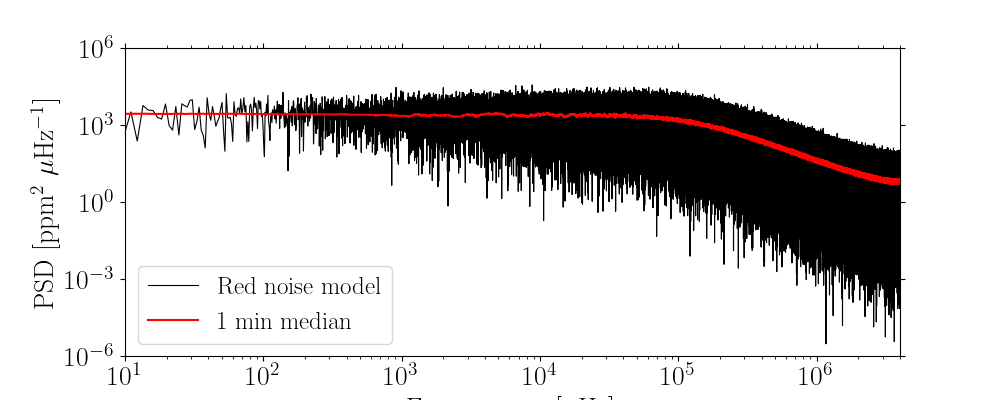

In [10]:
# Creaet plot
fig, ax = plt.subplots(1, 1, figsize=(10,4))

ax.plot(f_red, psd_red,     "k-", label="Red noise model", lw=0.8)
ax.plot(f_red, psd_red_med, "r-", label="1 min median")
ax.set_xlim(1e1, np.max(f_red))
ax.set_ylim(1e-6, 1e6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax.set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax.legend()
plt.show()

# Save figure
fig.savefig('jitter.png', bbox_inches='tight', dpi=200)

In [ ]:
# Old figure with OHB jitter included

# fig, ax = plt.subplots(2, 1, figsize=(10,8))

# ax[0].plot(f_prime, psd_prime,     "k-", label="Prime model")
# ax[0].plot(f_prime, psd_prime_med, "b-", label="1 min median")
# ax[1].plot(f_red, psd_red,         "k-", label="Red noise model")
# ax[1].plot(f_red, psd_red_med,     "r-", label="1 min median")

# for i in range(2):
#     ax[i].set_xlim(1e2, f_prime.max())
#     ax[i].set_ylim(1e-7, 1e6)
#     ax[i].set_xscale('log')
#     ax[i].set_yscale('log')

# fig.text(0.50, 0.04, r"Frequency, $\nu$ [$\mu$Hz]",   ha="center")
# fig.text(0.02, 0.50, r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]", va="center", rotation="vertical")
# ax[0].legend()
# ax[1].legend()
# plt.show()

# Save figure
# fig.savefig('jitter.pdf', bbox_inches='tight', dpi=200)

---
## CCD subfields
---

In [ ]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_Image"
sim = Simulation(outputFileName, outputDir=outputDir)

# Obs parameters
sim["ObservingParameters/NumExposures"]    = 1

# Sky parameters
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield 1000, 1100
rows, cols = 1000, 900
sim["SubField/NumColumns"]      = 400
sim["SubField/NumRows"]         = 400
sim["SubField/ZeroPointColumn"] = cols
sim["SubField/ZeroPointRow"]    = rows

# Run simulation
simfile0 = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig, ax = f0.showImage(0, clipPercentile=1.1, figsize=(10,10), colorMap="cubehelix",
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      fontSize=35)
# Save figure
fig.savefig('subfield400x400pix.png', bbox_inches='tight', dpi=200)

In [ ]:
# Find target from ,catalogue of Image
cat = simfile0.getStarCoordinates(0)
starID = 10
rowStar = int(cat[1][starID])
colStar = int(cat[2][starID])
fluxStar = int(cat[-1][starID])
rowStar, colStar

In [ ]:
# Initialise PlatoSim
outputFile = "output_imagette"
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = cols + colStar - 3
sim["SubField/ZeroPointRow"]    = rows + rowStar - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simfile = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f = SimFile(outputFile + ".hdf5")
fig, ax = f.showImage(0, figsize=(10,10), 
                      colorBar=True, imgScale="auto", colorMap="cubehelix",
                      showStarPositions="PIC", showStarIDs=False, useTitle=False,
                      showGrid=True, fontSize=30, tarMarkerSize=500) 

# # Save figure
fig.savefig('subfield6x6pix.png', bbox_inches='tight', dpi=200)

# Print the star magnitude used
f.getStarCatalog()[3]

---
## CTI for EOL
---

In [ ]:
# Initialise PlatoSim
sim = Simulation("output_CTI", outputDir=os.getcwd())

# Observation
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 200
sim["SubField/NumRows"]         = 200
sim["SubField/ZeroPointColumn"] = 2900
sim["SubField/ZeroPointRow"]    = 3100

# Save to HDF5
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

In [ ]:
# Load file
f = SimFile("output_CTI.hdf5")

# Show image
fig, ax = f.showImage(exp, colorMap="cubehelix", clipPercentile=0.8, figsize=(10,10),
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      colorBar=True, imgScale="auto", fontSize=20, showGrid=False, origin="upper")
ax.set_xlabel(r'Subfield pixel column, $i$')
ax.set_ylabel(r'Subfield pixel row, $j$')

# Save figure
fig.savefig('cti.png', bbox_inches='tight', dpi=200)

---
## Throughput map
---

In [3]:
exp = 1
outputFile = "output_TM"
sim = Simulation(outputFile, outputDir=os.getcwd())

In [ ]:
# # Initialise PlatoSim

# # Observation
# sim["ObservingParameters/BeginExposureNr"] = exp
# sim["ObservingParameters/NumExposures"]    = 1

# # Sky
# sim["Sky/SkyBackground"]         = -1  # Auto background
# sim["Sky/Cosmics/CosmicHitRate"] = 0

# # Subfield
# sim["SubField/NumColumns"]      = 4510
# sim["SubField/NumRows"]         = 4510
# sim["SubField/ZeroPointColumn"] = 0
# sim["SubField/ZeroPointRow"]    = 0

# # Save to HDF5
# sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# # Run simulation
# simFile = sim.run(removeOutputFile=True)

In [4]:
# Load file
f = SimFile(outputFile + ".hdf5")
tm = f.getThroughputMap(exp)
tm *= 100 * np.ones_like(tm)

# Get constants
pixelSize   = f.getInputParameter("CCD", "PixelSize")
focalLength = f.getInputParameter("Camera/FocalLength", "ConstantValue") * 1e3
ccdZeroPointX = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
ccdZeroPointY = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
distortionCoefficients = sim['Camera/FieldDistortion/ConstantCoefficients']

# Calculate diagonal offset betwee FP origo and CCD origo [deg]
alpha_offset = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(ccdZeroPointX, ccdZeroPointY, focalLength))

# Radial flux cut-off from stray light mask (undistorted and distorted)
alpha_max_und = np.deg2rad(18.9)
alpha_max_exp = np.deg2rad(20.0)
xFP_max_und, yFP_max_und = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_und, focalLength, inPlaneRotation=45.)
xFP_max_dis, yFP_max_dis = rf.undistortedToDistortedFocalPlaneCoordinates(xFP_max_und, yFP_max_und, distortionCoefficients, focalLength)
xFP_max_exp, yFP_max_exp = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_exp, focalLength, inPlaneRotation=45.)
xCCD_max_und, yCCD_max_und = rf.focalPlaneToPixelCoordinates(xFP_max_und, yFP_max_und, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
xCCD_max_dis, yCCD_max_dis = rf.focalPlaneToPixelCoordinates(xFP_max_dis, yFP_max_dis, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
xCCD_max_exp, yCCD_max_exp = rf.focalPlaneToPixelCoordinates(xFP_max_exp, yFP_max_exp, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
r_max_und = np.sqrt(xCCD_max_und**2 + yCCD_max_und**2)
r_max_dis = np.sqrt(xCCD_max_dis**2 + yCCD_max_dis**2)
r_max_exp = np.sqrt(xCCD_max_exp**2 + yCCD_max_exp**2)

# Find alpha_max in pixels
alpha = np.arange(0,22,2)
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(45))
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)

# Revert the inclusion of the QE
tm0 = tm / (sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"] * sim["CCD/QuantumEfficiency/MeanAngleDependency"])
tm0 = tm

In [36]:
# a = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(2.857, 2.857, focalLength))
r_max_dis

4794.371537669991

<IPython.core.display.Javascript object>


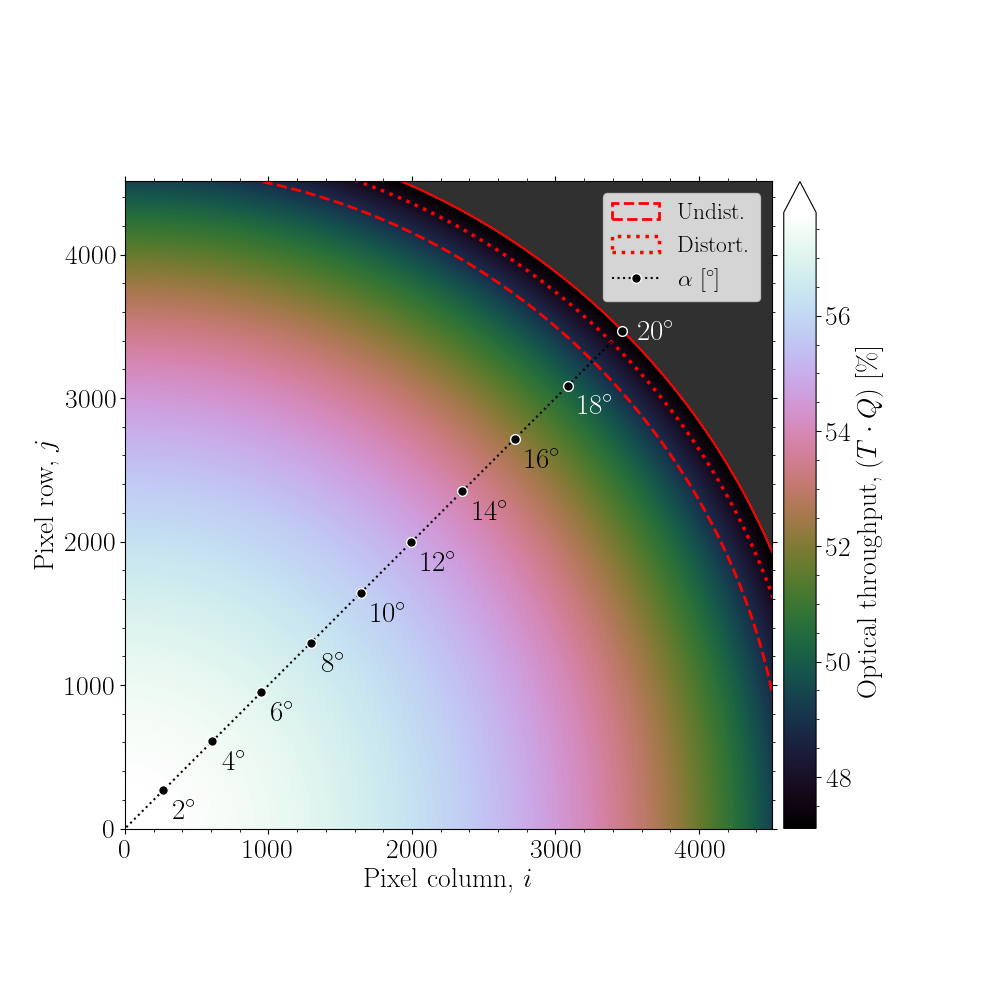

In [42]:
# Create plot
fig, ax = plt.subplots(1,1, figsize=(10,10))

# Set zero throughput to different color
tm1 = np.ma.masked_where(tm0 == 0, tm0)
cmap = plt.cm.cubehelix
cmap.set_bad(color='#303030')

im = ax.imshow(tm1, interpolation='nearest', extent=[0, 4510, 0, 4510], cmap=cmap, origin="lower",
               vmin=np.sort(np.unique(tm0))[1], vmax=np.max(tm0))

cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"Optical throughput, $(T \cdot Q)$ [\%]", labelpad=3)                                    
cbar.ax.tick_params()

# Plot circle 
ax.add_patch(patches.Circle((0, 0), r_max_und, color='r', ls="--", lw=2.0, fill=False, label="Undist."))
ax.add_patch(patches.Circle((0, 0), r_max_dis, color='r', ls=":",  lw=2.5, fill=False, label="Distort."))
ax.add_patch(patches.Circle((0, 0), r_max_exp, color='r', ls="-",  lw=1.5, fill=False)) #, label="Distort."))

# Plot distance indicator
ax.plot(xCCD, yCCD, "ko:", mec="w", ms=7, label=r"$\alpha$ [$^{\circ}$]")
for i in range(1,len(alpha)): 
    # Change color of labels
#     if i in (1, 2, 3, 4, len(alpha)-2, len(alpha)-1): color = "w"
    if i in (len(alpha)-2, len(alpha)-1): color = "w"
    else: color = "k"
    # Change position of labels
    if i == len(alpha)-1:
        ax.text(xCCD[i]+110, yCCD[i]-60, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    else:
        ax.text(xCCD[i]+70, yCCD[i]-200, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
ax.legend(loc='upper right', fontsize=17)
ax.set_xlim(0, 4510)
ax.set_ylim(0, 4510)
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('throughput.png', bbox_inches='tight', dpi=200)

In [ ]:
# T_opt = 0.
# T_fil = 1
# T_con = 0.972 * 0.9573
# T_pol = 0.989
# T_vin = 0.920
# QE = 0.6218
# T = T_opt * T_fil * T_con * T_pol * T_vin #* QE
# T

---
## PRNU
---

<IPython.core.display.Javascript object>


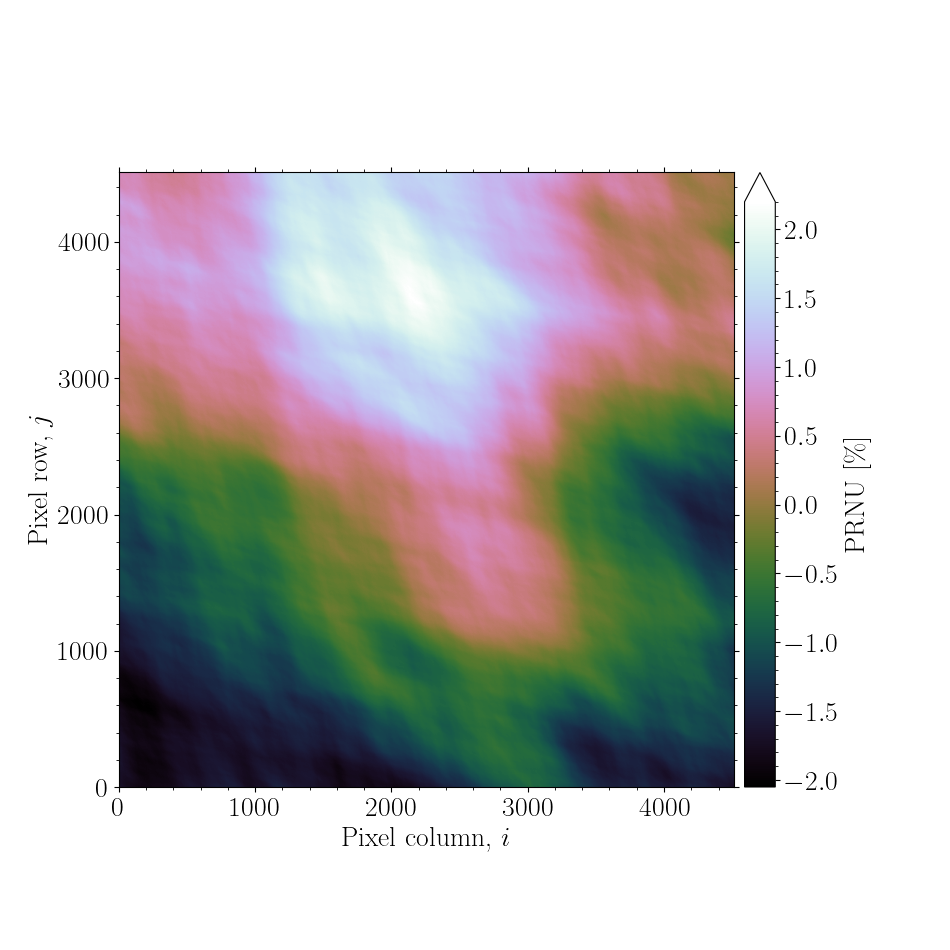

In [5]:
# We use the previous simulation to plot the flat-field [%]
prnu = (f.getPRNU() - 1) * 100

# Create plot
fig, ax = plt.subplots(1,1, figsize=(9.5,9.5))

im = ax.imshow(prnu, interpolation='nearest', extent=[0,4510,0,4510], cmap="cubehelix", origin="lower")
cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"PRNU [\%]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('prnu.png', bbox_inches='tight', dpi=200)

---
## Distortion
---

In [11]:
# Load Zemax PSF
f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
coorUnd = f["Coordinates map"]["Undistorted"]
coorDis = f["Coordinates map"]["Distorted"]

In [12]:
# Select data
xund   = coorUnd["x"][:]
yund   = coorUnd["y"][:]
xzemax = coorDis["x"][:]
yzemax = coorDis["y"][:]

# Unfortunately the HDF5 file is a mesh.. so we create a grid and select points from this
# x = np.arange(1.3, 85, 4.4)
# y = np.arange(1.3, 85, 4.4)
x = np.arange(1.3, 85, 8.8)
y = np.arange(1.3, 85, 8.8)

xx, yy = np.meshgrid(x,y)
coords = np.array((xx.ravel(), yy.ravel())).T

# Find indices that matches in undistorted grid point best
dex = []
for i in range(len(coords)):
    r = np.sqrt( (xund-coords[i,0])**2 + (yund-coords[i,1])**2 )
    dex.append(np.argmin(r))
xund   = np.array([xund[i] for i in dex])
yund   = np.array([yund[i] for i in dex])
xzemax = np.array([xzemax[i] for i in dex])
yzemax = np.array([yzemax[i] for i in dex])

# Calculate distortion using the Wang model for analytic PSFs
coeff = [0.32419,  0.0232909,  0.407979, 0.00022463, 0.000217599, 0.000381958, 0.000963902]
focalLength = 247.52
xwang, ywang = rf.undistortedToDistortedFocalPlaneCoordinates(xund, yund, coeff, focalLength)

# For plotting FOV limit
fov_max = np.deg2rad(18.8908)
fov_max_mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(fov_max, focalLength)[0]

# Remove extra data at deges
rm = [39, 49, 58, 59, 67, 68, 69, 76, 77, 78, 79, 85, 86, 87, 88, 89, 93, 94, 95, 96, 97, 98, 99]
xund = np.delete(xund, rm) 
yund = np.delete(yund, rm) 
xwang = np.delete(xwang, rm) 
ywang = np.delete(ywang, rm) 
xzemax = np.delete(xzemax, rm) 
yzemax = np.delete(yzemax, rm) 

# Find the radial distance from OA for data
alpha = np.rad2deg([rf.gnomonicRadialDistanceFromOpticalAxis(xund[i], yund[i], focalLength) 
                    for i in range(len(xund))])

<IPython.core.display.Javascript object>


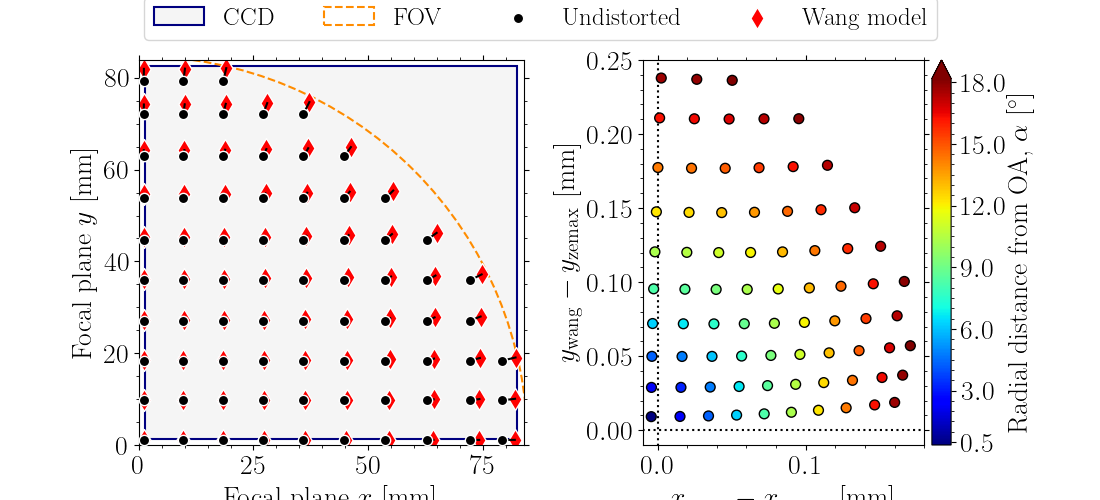

In [14]:
# Plot image
fig, ax = plt.subplots(1, 2, figsize=(11,5))

# Plot CCD and FOV footprint
ax[0].add_patch(patches.Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='whitesmoke', lw=1.5, label="CCD"))
ax[0].add_patch(patches.Circle((0, 0), fov_max_mm, color='darkorange', ls="--", lw=1.5, fill=False, label="FOV"))
ax[0].scatter(xund,   yund,   s=55,  c="k", edgecolor='w', marker="o", label="Undistorted",      zorder=3)
ax[0].scatter(xwang,  ywang,  s=125, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)
for i in range(len(xund)):
    ax[0].plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# Plot residuals between Wang / Zemax
ax[1].hlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
ax[1].vlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
im = ax[1].scatter(xwang-xzemax, ywang-yzemax, s=50, c=alpha, cmap="jet", edgecolor='k', marker="o", 
                   label="Zemax model", zorder=1)
# Set colorbar
cbar = fig.colorbar(im, extend='max', shrink=1.0, pad=0.02, ticks=[0.5,3,6,9,12,15,18])
cbar.set_label(r"Radial distance from OA, $\alpha$ [$^{\circ}$]", labelpad=0)
# cbar.ax.tick_params(labelsize=fontSize)

# subplot 0
ax[0].set_xlabel(r"Focal plane $x$ [mm]")
ax[0].set_ylabel(r"Focal plane $y$ [mm]")
ax[0].set_aspect('equal', 'box')
ax[0].set_xlim(0, 82.48+1.4)
ax[0].set_ylim(0, 82.48+1.4)
ax[0].legend(fontsize=18, ncols=4, bbox_to_anchor=(-0.02, 1.02))

# subplot 0
ax[1].set_xlabel(r"$x_{\rm wang} - x_{\rm zemax}$ [mm]")
ax[1].set_ylabel(r"$y_{\rm wang} - y_{\rm zemax}$ [mm]")
ax[1].set_aspect('equal', 'box')
ax[1].set_xlim(-0.01, 0.18)
ax[1].set_ylim(-0.01, 0.25);

# Save figure
fig.savefig('distortion.png', bbox_inches='tight', dpi=200)

---
## Vignetting
---

In [ ]:
# # A few constants
# alpha_max = 18.8908
# r = np.linspace(0, alpha_max, 1000)

# # Natural vignetting
# def T_nat(r):
#     return 1 - np.cos(np.deg2rad(r))**2

# # Optical vignetting
# def T_opt(r):
#     sim = Simulation("out")
#     c = sim["CCD/RelativeTransmissivity/Coefficients"]
#     return c[0] * r**2 + c[1] * r**4 + c[2] * r**6

In [ ]:
# # Plot figure
# fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# # Response functions:
# ax.plot(r, T_opt(r)+T_vig(r), 'k-', label='Total')
# ax.plot(r, T_nat(r), '--', c="darkcyan", label='Natural')
# ax.plot(r, T_opt(r), ':',  c="deeppink", label='Optical')
# ax.axvspan(alpha_max, alpha_max+1, color='k', alpha=0.1, lw=0, label="Mechanical")
# # ax.set_yscale('log')
# ax.set_xlabel(r"Radial distance from optical axis, $\alpha$ [deg]")
# ax.set_ylabel("Vignetting")
# ax.set_xlim(0, alpha_max+1)
# ax.set_ylim(0, 19)
# ax.legend();

---
## Spectral transmission
---

In [ ]:
# Import PLATO passband
path = "/lhome/nicholas/Nextcloud/Platoman/Models/TOU"
data = np.loadtxt(f"{path}/optical_transmission_ncam.txt")

In [ ]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(data[:,0],  data[:,1], 'bo-', label='BOL')
ax.plot(data[:,0],  data[:,2], 'ro-', label='EOL') 
# ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
# ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
# ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(450, 1050)
ax.set_ylim(0.5, 1)
ax.legend()
plt.show()

# Save figure
# fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

---
## Microscanning
---

In [15]:
# Constants
cadence  = 25.  # [s]                                                                                                                                                                             
quarter  = 0                                                                                                                                                                                           
day = 86400.                                                                                                                                                                                            

# Load file
filename_bc = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/microscan_spiral_8Hz_3h_BC.txt'
filename_wc = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/microscan_spiral_8Hz_3h_WC_01.txt'

data_bc = np.loadtxt(filename_bc)
data_wc = np.loadtxt(filename_wc)
t_bc, x_bc, y_bc, z_bc = data_bc[:,0], data_bc[:,1], data_bc[:,2], data_bc[:,3]
t_wc, x_wc, y_wc, z_wc = data_wc[:,0], data_wc[:,1], data_wc[:,2], data_wc[:,3]

time_points = round(t_bc[-1] / cadence)
timeStart   = round(90. * quarter * day)                                                                                                                                                                   
timeEnd     = round(timeStart + time_points * cadence)                                                                                                                                                    
time        = np.arange(timeStart, timeEnd, cadence)

# Find points at cadence
dex_bc = [ut.findNearestIndex(t_bc, time[i]) for i in range(len(time))]
dex_wc = [ut.findNearestIndex(t_wc, time[i]) for i in range(len(time))]

<IPython.core.display.Javascript object>


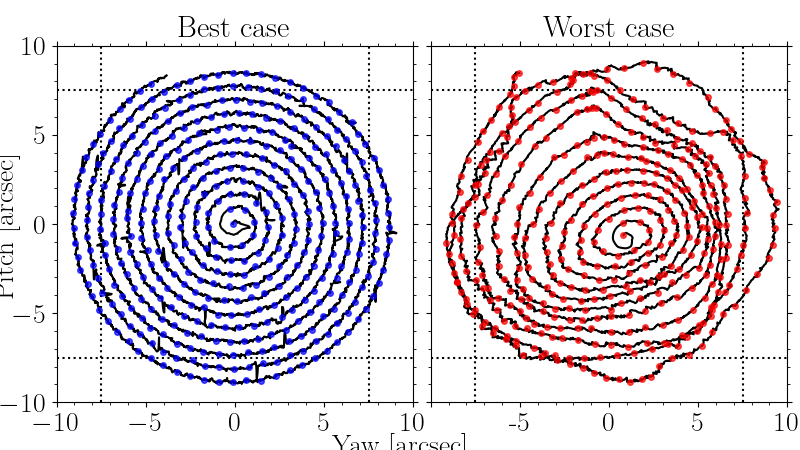

/tmp/ipykernel_145543/4016711954.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].xaxis.set_ticklabels(["","-5","0", "5", "10"])


In [17]:
# Plot spiral
fig, ax = plt.subplots(1, 2, figsize=(8,4.5))

# Plots
for i in range(2):
    ax[i].axvline(x=-7.5, color='k', linestyle=':')
    ax[i].axvline(x=+7.5, color='k', linestyle=':')
    ax[i].axhline(y=-7.5, color='k', linestyle=':')
    ax[i].axhline(y=+7.5, color='k', linestyle=':')
ax[0].plot(x_bc, y_bc, 'k-')
ax[1].plot(x_wc, y_wc, 'k-')
ax[0].plot(x_bc[dex_bc], y_bc[dex_bc], 'bo', alpha=0.7, ms=4)
ax[1].plot(x_wc[dex_wc], y_wc[dex_wc], 'ro', alpha=0.7, ms=4)

# Labels
ax[0].set_title('Best case', fontsize=22)
ax[1].set_title('Worst case', fontsize=22)                                                                                                                                                                        
fig.text(0.50, -0.01, 'Yaw [arcsec]',   ha="center")
fig.text(-0.01, 0.50, 'Pitch [arcsec]', va="center", rotation=90)

# Settings
for i in range(2):
    ax[i].set_xlim(-10,10)
    ax[i].set_ylim(-10,10)
    ax[i].set_aspect('equal', 'box')
    ax[i].locator_params(axis='x', nbins=5)
    ax[i].locator_params(axis='y', nbins=5)
ax[1].yaxis.set_ticklabels([])
ax[1].xaxis.set_ticklabels(["","-5","0", "5", "10"]) 
plt.tight_layout(pad=-0)                                                                                                                                                                                      
plt.show()

# Save figure
fig.savefig('microscans.png', bbox_inches='tight', dpi=200)

---
## Photometry
---

In [ ]:
# Outputs
outputDir      = os.getcwd()
outputFileName = "output_photometry"

# Set up a Simulation object
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Obs
sim["ObservingParameters/NumExposures"] = int(88*86400/25.)

# Subfield
sim["SubField/ZeroPointRow"]    = 1000
sim["SubField/ZeroPointColumn"] = 1000
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8

# Sky background
sim["Sky/SkyBackground"]               = -1
sim["Sky/Cosmics/CosmicHitRate"]       = 10
sim["Sky/IncludeCosmicsInSubField"]    = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"] = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]     = "yes"   
#sim["Sky/IncludeVariableSources"]                 = "no"
#sim["Sky/VariableSourceList"]                     = "myVariableStar.txt"

# PSF
sim["PSF/Model"] = "AnalyticNonGaussian"

# Photometry
sim["Photometry/IncludePhotometry"]  = "yes"
sim["Photometry/MaskUpdateInterval"] = 14

# Output
sim.writeAllOutputToHDF5(False)
sim["ControlHDF5Content/WritePixelMaps"]     = True                                                                             
sim["ControlHDF5Content/WriteStarPositions"] = True

In [ ]:
# Define catalogue
row = np.array([4.0]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0])
ID  = [0]

# Create the catalogue file
starcatFile = os.getcwd() + "/inputfile_starcat.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [ ]:
# Create photometry file (this function automatically sets the file as well)
photometryFile = os.getcwd() + "/inputfile_photometry.txt"
sim.createPhotometryTargetFile(ID[0], photometryFile)

In [ ]:
# Create a drift file (this function automatically sets the file as well)
driftFile = os.getcwd() + "/inputfile_drift.txt"
sim.createDriftFile(quarter=range(1,2), fileName=driftFile, plot=True, model="linear") 

In [ ]:
sim.getReadoutTime()

In [ ]:
# Run the simulation
f = sim.run(removeOutputFile=True, executionTime=True)

In [ ]:
# First check the subfield looks good
fig, ax = f.showImage(imgScale="clip", fontSize=20, showStarPositions="PIC",
                      colorBar=True, showGrid=True, showMaskOfStarID=0)

In [ ]:
# Load light curve objects
lc = LightCurve(outputFileName + ".hdf5")

In [ ]:
# Show the light curve (mask update events are show automatically)
fig, ax = lc.plot(median_filter=1, flux_unit="e/s", legend=False, figsize=(8.5,4));
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_yticks([140000, 142000, 144000, 146000])
fig.savefig('photometry.png', bbox_inches='tight', dpi=200)

---
## Earth-like transit
---

In [43]:
# Load all data for a single star
# idir = "/lhome/nicholas/data/platosimPaper/SunEarth_Tran"
idir = "/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls"
# idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_Tran"
# idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_TranGranPuls"
lcs = LightCurve(idir+'/detrended_mag10', mode="multi")

In [ ]:
# lcs.files('ftr')

In [ ]:
# Unzip all compressed files for the same star
# lcs.unpack()

In [44]:
# Get parameter used in input model
lc = LightCurve(lcs.files('ftr')[0])
df_var  = lc.varsource()
varinfo = lc.varsource_info()
P    = varinfo.P_day[0]
t0   = varinfo.t0_day[0]
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Transit duration : {tdur*24:.2f} hours')

Transit duration : 12.97 hours


In [45]:
lc.data()

,time,flux,flux_err,flux_trend,flux_detrend,flux_clip,bg,bg_err,cx,cx_err,cy,cy_err
0,18.75,405806.493034,169.840371,406205.807878,-983.035783,-983.035783,1998.231968,12.647739,2.874434,0.001015,3.164027,0.000985
1,43.75,405385.305088,169.796495,406205.396594,-2018.908444,-2018.908444,2024.426389,12.681930,2.873054,0.001013,3.164201,0.000987
2,68.75,405914.532061,169.891259,406204.987189,-715.045696,-715.045696,2023.415495,12.680592,2.877098,0.001018,3.165001,0.000986
3,93.75,407050.367577,170.087374,406204.767959,2081.707761,2081.707761,2005.917199,12.659862,2.879893,0.001020,3.160027,0.000983
4,118.75,404604.670541,169.662539,406204.810457,-3939.244131,-3939.244131,2021.047882,12.679649,2.878025,0.001021,3.161638,0.000986
...,...,...,...,...,...,...,...,...,...,...,...,...
303292,7603068.75,402463.915216,169.362998,403386.139996,-2286.208394,-2286.208394,2024.899458,12.692635,2.684075,0.000820,3.459777,0.001130
303293,7603093.75,402357.447440,169.328760,403385.839634,-2549.400829,-2549.400829,2037.283491,12.703756,2.687315,0.000823,3.457934,0.001130
303294,7603118.75,402702.403463,169.397914,403385.671603,-1693.833441,-1693.833441,2022.347888,12.688481,2.685820,0.000822,3.456921,0.001127
303295,7603143.75,404633.423900,169.732674,403385.590505,3093.401014,3093.401014,2015.058820,12.677667,2.685179,0.000818,3.459570,0.001125


In [ ]:
# # Merge all data across cameras and quarter
# ofile = f'{idir}/../lc_combined_mag10.ftr'
# lc = lcs.merge(ofile=ofile, flux_group_mean=True)

In [46]:
# Laod the merged detrended light curves
ofile = f'{idir}/../lc_combined_mag10.ftr'
lc = LightCurve(ofile)
df = lc.data()
df

,time,flux,flux_err,flux_trend,flux_detrend,flux_clip
0,0.000000e+00,409133.549367,168.426012,409399.358144,-649.145917,-649.145917
1,6.250000e+00,396498.496678,168.112629,396535.750207,-93.938954,-93.938954
2,1.250000e+01,392299.195139,167.046219,392586.414700,-731.505503,-731.505503
3,1.875000e+01,406304.110556,169.910424,406277.889367,62.820052,62.820052
4,2.500000e+01,409222.989887,168.431378,409399.420068,-431.123216,-431.123216
...,...,...,...,...,...,...
15794936,1.009151e+08,392313.667695,168.486453,392427.839457,-290.936959,-290.936959
15794937,1.009152e+08,381485.253838,166.663746,381370.675029,300.419769,300.419769
15794938,1.009152e+08,393166.558146,168.665353,392428.053468,1881.885537,1881.885537
15794939,1.009152e+08,381525.245415,166.667711,381370.678526,404.917513,404.917513


In [83]:
# Shorten and save
# tmax = df.time.iloc[-1]/day
# df_short = df[df.time < tmax*day]

# Select specific times span
# df_short = df[df.time < 1000*day]
df_short = df[(df.time > 100*day) & (df.time < 1200*day)]

In [84]:
# Remove bad detrended data
df_short = df_short.drop(df_short[(df_short.time > 338*day) & (df_short.time < 341*day)].index)

In [85]:
# Define parameters
time = df_short.time/day
flux = df_short.flux_detrend
time_var = df_var.time/day
flux_var = df_var.comb
flux_tra = df_var.tran

In [73]:
# Compute PSD for Prime data
freq_gran, psd_gran = periodogram(df_var.gran, 1/25, scaling='density')
freq_puls, psd_puls = periodogram(df_var.puls, 1/25, scaling='density')
freq_tran, psd_tran = periodogram(df_var.tran, 1/25, scaling='density')
freq_gran *= 1e6  # [muHz]
freq_puls *= 1e6  # [muHz]
freq_tran *= 1e6  # [muHz]

In [74]:
freq_sim, psd_sim = periodogram(flux, 1/25, scaling='density')
freq_sim *= 1e6  # [muHz]

<IPython.core.display.Javascript object>


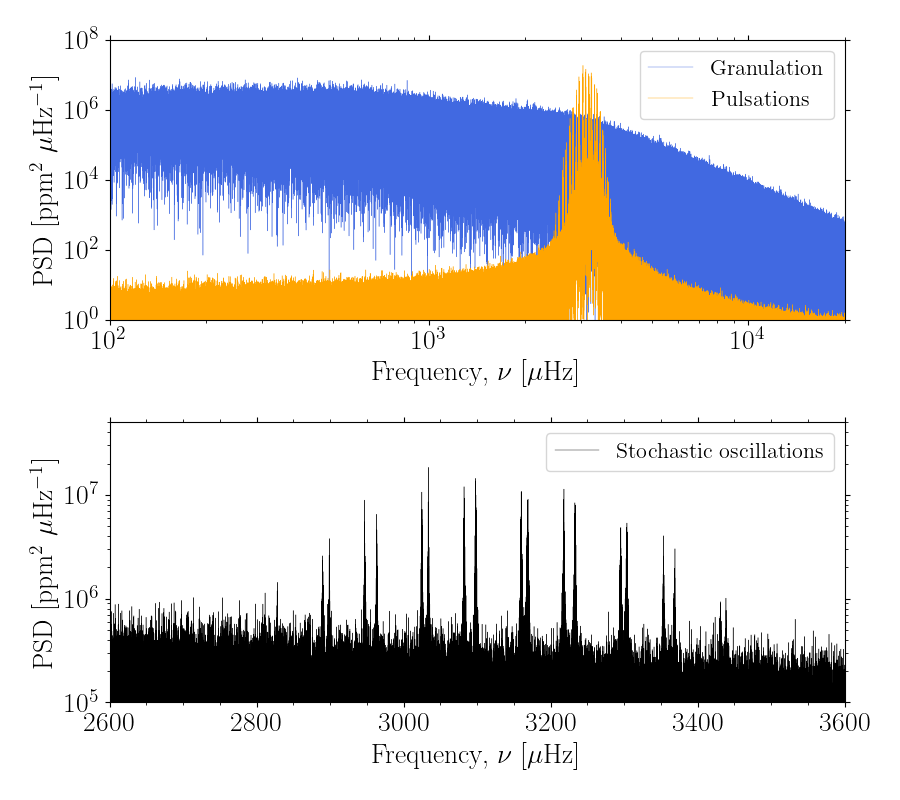

In [75]:
# Creaet plot
fig, ax = plt.subplots(2, 1, figsize=(9,8))
# Plot global model
ax[0].plot(freq_gran, psd_gran, "-", c='royalblue', lw=0.3, label="Granulation")
ax[0].plot(freq_puls, psd_puls, "-", c='orange', lw=0.3, label="Pulsations")
ax[0].set_xlim(1e2, np.max(freq_gran))
ax[0].set_ylim(1e0, 1e8)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[0].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[0].legend(ncol=1, loc='upper right', fontsize=16)
# Plot global model
ax[1].plot(freq_puls, psd_gran+psd_puls, "-", c='k', lw=0.3, label="Stochastic oscillations")
ax[1].set_xlim(2600, 3600)
ax[1].set_ylim(1e5, 0.5e8)
# ax[1].set_xticks([2.5e3, 3.0e3, 3.5e3, 4.0e3])
# ax[1].set_xticklabels(['2500','3000','3500','4000'])
# ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[1].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[1].legend(ncol=1, loc='upper right', fontsize=16)
# ax.plot(f_red, psd, "r-", label="1 min median")
plt.tight_layout()

# Save figure
fig.savefig('oscillations.png', bbox_inches='tight', dpi=200)

In [86]:
# Mask transits using Wotan
mask = wotan.transit_mask(time=time, period=P, duration=tdur, T0=t0)

In [87]:
# Resample (bin) data using scipy
from scipy.stats import binned_statistic
flux_bin, time_bin, nbin = binned_statistic(time, flux, statistic='median', bins=int(tmax*24))
time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
# tim_short = df_short.drop(df_short[(df_short.time > 338*day) & (df_short.time < 341*day)].index)

In [88]:
# Remove extreme outliers
time_bin = time_bin[(flux_bin > -200) & (flux_bin < 200)]
flux_bin = flux_bin[(flux_bin > -200) & (flux_bin < 200)]

<IPython.core.display.Javascript object>


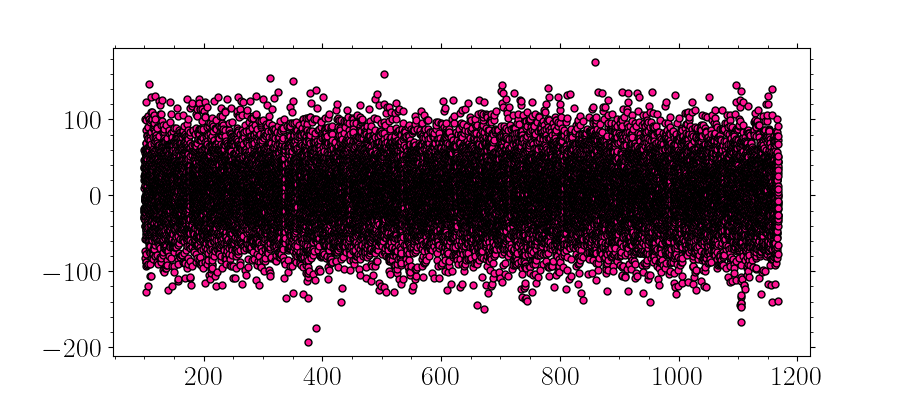

In [89]:
# Plot the corrected timeseries
plt.figure(figsize=(9,4))
plt.plot(time_bin, flux_bin, '.', c='deeppink', ms=10,  alpha=1.0, mec='k', label='1h bins');
# plt.plot(time_var, flux_tra, '-', c='orange',   lw=2,   alpha=1.0, label='TLS fit')

<IPython.core.display.Javascript object>


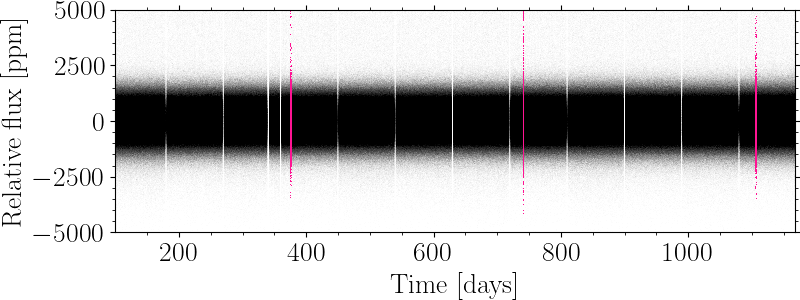

In [90]:
# Plot the corrected timeseries
fig, ax = plt.subplots(1, 1, figsize=(8,3))
ax.plot(time,       flux,       ',', c='k', ms=1.0, alpha=0.01)
ax.plot(time[mask], flux[mask], ',', c='deeppink', ms=1.0, alpha=1)
# Labels
ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"Relative flux [ppm]")
# Settings
ax.set_xlim(np.min(time), np.max(time))
ax.set_ylim(-5000, 5000)
plt.tight_layout(pad=0.0)

In [91]:
# Save an light curve to perform TLS from a script: time [days], flux [mean to 1]
df_tot = pd.DataFrame({'time': time.to_numpy(), 'flux': flux.to_numpy()/1e6+1})
df_bin = pd.DataFrame({'time': time_bin,        'flux': flux_bin/1e6+1})
df_tot.to_feather(f'{idir}/lc_final_tot.ftr')
df_bin.to_feather(f'{idir}/lc_final_bin.ftr')
df_bin.to_csv(f'{idir}/lc_final_tot.csv')

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 54 durations
Searching 27386 data points, 41749 periods from 10.0 to 399.989 days
Using 10 of 12 CPU threads


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41749/41749 periods | 02:30<00:00


Searching for best T0 for period 365.27840 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27386/27386 [00:08<00:00, 3056.63it/s]


Period 365.27840 d
3 transit times in time series: ['375.20841', '740.48682', '1105.76522']
Transit depth 0.99990
Best duration (days) 0.56677
Signal detection efficiency (SDE): 191.97763347697978


<IPython.core.display.Javascript object>


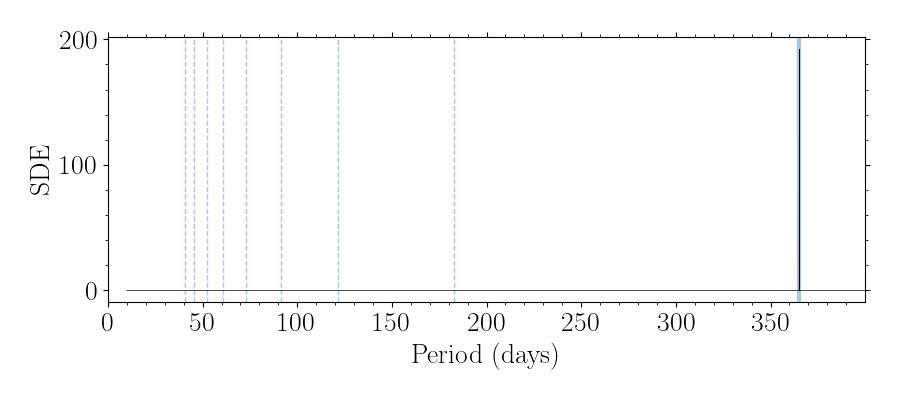

In [92]:
# Perform TLS vetting
# model   = tls.transitleastsquares(time.to_numpy(), flux.to_numpy()/1e6+1)
model   = tls.transitleastsquares(time_bin, flux_bin/1e6+1)
results = model.power(R_star=1.0,
                      R_star_min=0.13,
                      R_star_max=2.50,
                      M_star=1.0,
                      M_star_min=0.1,
                      M_star_max=1.2,
                      period_min=10.0, 
                      period_max=400.0,
                      n_transits_min=2,
                      use_threads=10);

print('Period', format(results.period, '.5f'), 'd')
print(len(results.transit_times), 'transit times in time series:', \
        ['{0:0.5f}'.format(i) for i in results.transit_times])
print('Transit depth', format(results.depth, '.5f'))
print('Best duration (days)', format(results.duration, '.5f'))
print('Signal detection efficiency (SDE):', results.SDE)
# Store result
phase_res = results.model_folded_phase
flux_res  = (results.model_folded_model-1)*1e6

# Plot SDE
plt.figure(figsize=(9,4))
ax = plt.gca()
ax.axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax.axvline(n*results.period,   alpha=0.4, lw=1, linestyle="dashed")
    ax.axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
plt.ylabel(r'SDE')
plt.xlabel('Period (days)')
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(0, max(results.periods))
plt.tight_layout();

In [69]:
results.snr

14.591373418803379

In [32]:
# Prepare for phase plot
from PyAstronomy import pyasl
from scipy.stats import binned_statistic
# For data
phase = pyasl.foldAt(time, P, T0=t0+P/2)
sort  = np.argsort(phase)
# For variable
phase_var = pyasl.foldAt(time_var, P, T0=t0+P/2)
sort_var  = np.argsort(phase_var)
# Binned data
phase_bin = pyasl.foldAt(time_bin, P, T0=t0+P/2)
sort_bin  = np.argsort(phase_bin)

#### Combined plot for paper

<IPython.core.display.Javascript object>


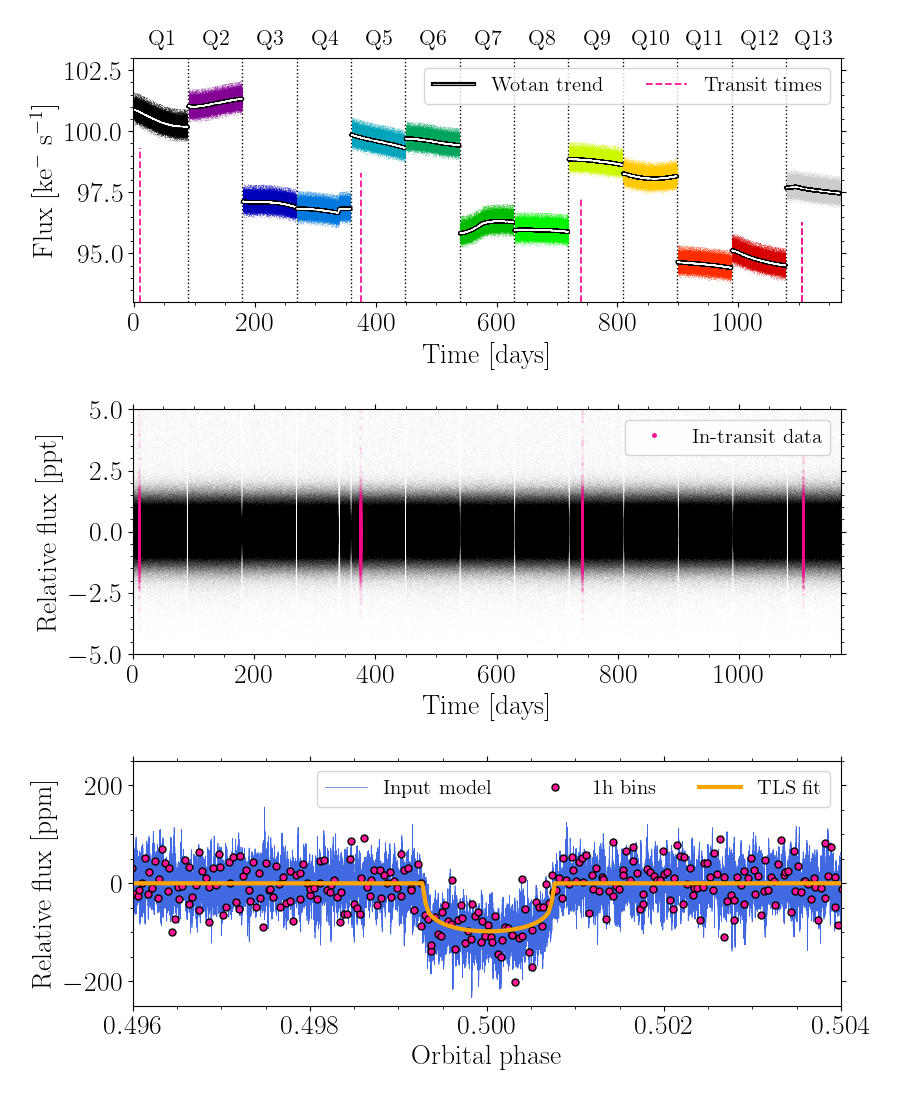

In [34]:
# Create overview plot of transit vetting
fig, ax0 = lcs.plot_multi(group=1, camera=1, quarter=False, figsize=(9,11))
ax0.set_ylim(93, 103)
# Plot transit times for ax 0 and 1
ymax = 0.73
transit_times = np.arange(t0, 4*P, P)
for T in transit_times:
    ymax -= 0.10 
    ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3)
    if T == transit_times[-1]:
        ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3, label='Transit times')
#     ax1.axvline(x=T, ymax=0.1,  c='deeppink', linestyle='--', lw=1.3)
ax0.legend(loc='upper right', ncols=2, fontsize=15, frameon=True)
    
# Plot the corrected timeseries
ax1 = fig.add_subplot(312)
ax1.plot(time,       flux/1e3,       ',', c='k', ms=1.0, alpha=0.01)
ax1.plot(time[mask], flux[mask]/1e3, '.', c='deeppink', ms=0.1, alpha=1, label='In-transit data')
# Labels
ax1.set_xlabel(r"Time [days]")
ax1.set_ylabel(r"Relative flux [ppt]")
# Settings
leg1 = ax1.legend(loc='upper right', ncols=1, fontsize=15, frameon=True)
# leg1.legendHandles[0]._legmarker.set_alpha(1)
leg1.legendHandles[0].set_markersize(5)
ax1.set_xlim(np.min(time), np.max(time))
ax1.set_ylim(-5, 5)

# Plot the corrected timeseries
ax2 = fig.add_subplot(313)
ax2.plot(phase_var[sort_var], flux_var[sort_var], '-', c='royalblue',   lw=0.5, alpha=1.0, label='Input model')
ax2.plot(phase_bin[sort_bin], flux_bin[sort_bin], '.', c='deeppink', ms=10,  alpha=1.0, mec='k', label='1h bins')
# ax2.plot(phase_var[sort_var], flux_tra[sort_var], '-', c='w', lw=5)
ax2.plot(phase_res, flux_res, '-', c='orange', lw=3, label='TLS fit')
# Labels
ax2.set_xlabel(r"Orbital phase")
ax2.set_ylabel(r"Relative flux [ppm]")
ax2.legend(loc='upper right', ncols=3, fontsize=15, frameon=True)
# Settings
ax2.set_xlim(0.496, 0.504)
ax2.set_ylim(-250, 250)
# ax2.set_ylim(-2000, 1000)

# Save the figure
plt.tight_layout(w_pad=0.5)
fig.savefig('transit.png', bbox_inches='tight', dpi=200);    

---
## NSR vs. P passband
---

In [3]:
# User parameters
numStar = 400
simDir  = "/lhome/nicholas/data/kul21"
resultDir = "/lhome/nicholas/software/PlatoSim3/docs/technicalnotes/KUL-TN-21"
inputDirNone  = simDir + "/jitterNone"
inputDirRed   = simDir + "/jitterRed"
inputDirPrime = simDir + "/jitterPrime"
outputFileNoneMerged  = resultDir + "/resultsJitterNoneMerged.ftr"
outputFileRedMerged   = resultDir + "/resultsJitterRedMerged.ftr"
outputFilePrimeMerged = resultDir + "/resultsJitterPrimeMerged.ftr"

In [4]:
# Load results and sort logically
df3 = pd.read_feather(outputFilePrimeMerged)
df3_tar = df3.loc[df3["ncon"] == 0]
df3.head()

,index,star,mag,rOA,quarter,ncam,ncon,SPR,NSR,flux_err,flag
0,0,1,9.64,12.928107,1,17,1,0.156194,27.398323,514.820801,0.0
1,1,1,9.64,12.928107,2,6,1,0.156194,47.316532,521.660217,0.0
2,2,1,9.64,12.928107,3,18,1,0.156194,26.957983,512.033386,0.0
3,3,1,9.64,12.928107,4,6,1,0.156194,45.958900,511.705231,0.0
4,4,1,9.64,12.928107,5,18,1,0.156194,26.644508,513.687805,0.0


In [5]:
import matplotlib as mpl
cmap = mpl.cm.get_cmap('coolwarm')
rgba = [] # the color container
for value in [0, 0.33, 0.66, 0.8]:
    rgba.append(cmap(value)) 
rgba

[(0.2298057, 0.298717966, 0.753683153, 1.0),
 (0.6619678959411764, 0.7754914668823529, 0.9939365253764706, 1.0),
 (0.9675442976352941, 0.7308497161882352, 0.6246854782352941, 1.0),
 (0.9318312966, 0.5190855232, 0.4064796086, 1.0)]

In [ ]:
# Plot multi-camera simulation
fig, ax = pt.plotNSRvsMagnitude(df3_tar, column="ncam", residuals="multi", grid=False, figsize=(7.5,6))
plt.tight_layout(pad=0.0)
# Save plot
fig.savefig('NSRvsP.png', bbox_inches='tight', dpi=200)

---
## Synthetic PSF: Zemax and Analytic
---

In [3]:
# Initialise PlatoSim
outputFileName = "output_PSF_test"
sim = Simulation(outputFileName, outputDir=os.getcwd())
pixelSize   = sim["CCD/PixelSize"]                            # [um]
focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000  # [mm]
ccdAngles   = sim["CCDPositions/Orientation"]

# Set global parameters for this section
fs = 25
cm = 'gist_stern'
res_z = 64   # Zemax    PSF resolution [subpixel/pixel]
res_a = 128  # Analytic PSF resolution [subpixel/pixel]
sub2pix_z = [0, res_z, int(res_z*2), int(res_z*3), int(res_z*4)]
sub2pix_a = [0, res_a, int(res_a*2), int(res_a*3), int(res_a*4)]
ticks =["0", "1", "2", "3", "4"]

# Constants
deg2mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(1), focalLength)[0]
deg2pix = 240

In [4]:
xFP, yFP   = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(16), focalLength, inPlaneRotation=np.deg2rad(30))
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)
print(xFP, yFP)
print(xCCD, yCCD)

61.46634172583103 35.48760894151006
3414.7967625461683 1971.5338300838923


In [5]:
x1 = 2.13
x2 = 13.165
alpha = rf.gnomonicRadialDistanceFromOpticalAxis(x1*deg2mm, x1*deg2mm, focalLength)
print(xCCD, yCCD)
print(np.rad2deg(alpha))

3414.7967625461683 1971.5338300838923
3.009809192321929


In [6]:
# Define small function for common settings
def runsim(sim, ccdCode, xCCD, yCCD, N=8):
    
    # Observation
    sim["ObservingParameters/NumExposures"] = 1

    # Camera
    sim["Camera/IncludePointLikeGhosts"] = False 

    # PSF
    sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

    # Control HDF5
    sim["ControlHDF5Content/WriteStarPositions"]     = True
    sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
    sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

    # Set subfiled
    # Note setting the coordinates only will only allow to 
    setSubfield = sim.setSubfieldAroundPixelCoordinates(ccdCode=ccdCode, 
                                                        xCCDpixel=xCCD, yCCDpixel=yCCD, 
                                                        subfieldSizeX=8, subfieldSizeY=8)
    # Run simulation
    sim.run(removeOutputFile=True)

### Test case: Analytic non-Gaussian

In [11]:
# Check coordinate from Carsten's plot
ccdCode = "1"
xCCDdeg = x1 + 5 * 2
yCCDdeg = x1 + 5 * 1
xCCD = xCCDdeg * deg2pix
yCCD = yCCDdeg * deg2pix 

# Initialise PlatoSim
outputFileName = "output_AnalyticPSF_test"
sim = Simulation(outputFileName, outputDir=os.getcwd())
sim["PSF/Model"] = "AnalyticNonGaussian"
runsim(sim, ccdCode, xCCD, yCCD)


2023-02-08 15:29:00 WARNING Sky::zodiacalFlux(): No data for (alpha, delta) = (76.447511, -64.750476)
2023-02-08 15:29:00 WARNING Simulation: no information about detected stars to write to HDF5
2023-02-08 15:29:00 WARNING Camera: No star positions to write to HDF5 file.



<IPython.core.display.Javascript object>


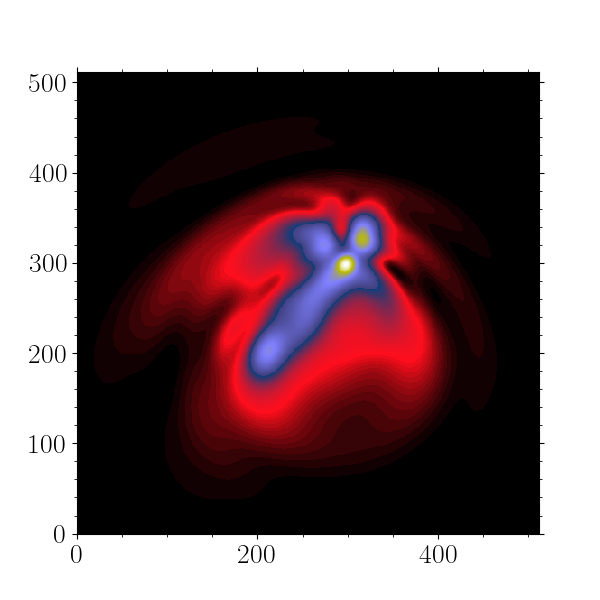

180


In [12]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(6,6))
fig.subplots_adjust(hspace=0.02, wspace=0)
# Load correct PSF
string = "output_AnalyticPSF_test"
f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
psf = np.array(f["PSF/highResPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a] 
# Rotate psf
angles = [180, 90, 0, 270]
# angles = [270, 180, 270, 0]
rotate = angles[int(ccdCode)-1]
psf_rot = scipy.ndimage.rotate(psf, rotate)
# Plot PSF
im = ax.imshow(psf_rot, cmap=cm, interpolation='nearest', origin='lower')
print(rotate)

### Test case: Zemax

In [138]:
# Coordinate corresponding to (-2.5, -2.5) in Carstens plot
# Warning! Zemax is alway using a CCD number lower than the Analytic!
ccdCode = "2"
xFPdeg = 2.5 + 5 * 3
yFPdeg = 2.5 + 5 * 1
xFPmm = xFPdeg * deg2mm
yFPmm = yFPdeg * deg2mm
xCCD = xFPdeg * deg2pix
yCCD = yFPdeg * deg2pix 
print(xCCD, yCCD)

# Initialise PlatoSim
outputFileName = "output_ZemaxPSF_test"
sim = Simulation(outputFileName, outputDir=os.getcwd())
sim["PSF/Model"] = "MappedFromFile"
runsim(sim, ccdCode, xCCD, yCCD)

4200.0 1800.0

2023-01-27 15:29:25 WARNING Simulation: no information about detected stars to write to HDF5
2023-01-27 15:29:25 WARNING Camera: No star positions to write to HDF5 file.



<IPython.core.display.Javascript object>


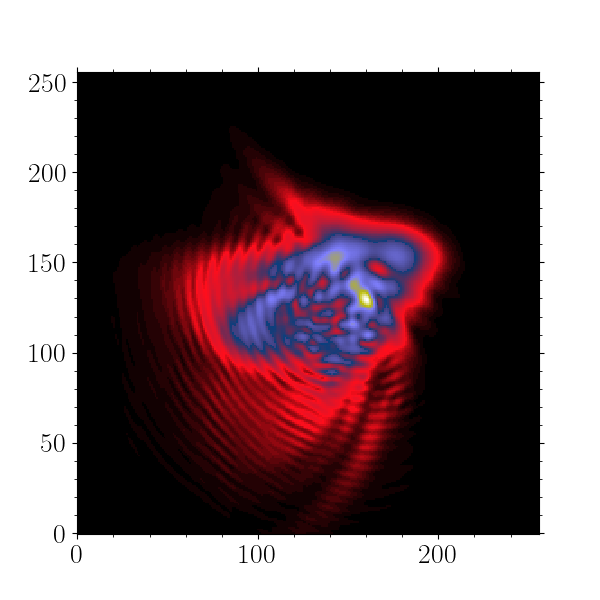

In [139]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(6,6))
fig.subplots_adjust(hspace=0.02, wspace=0)
# Load correct PSF
string = "output_ZemaxPSF_test"
f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
psf = np.array(f["PSF/rotatedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z] 
# Rotate psf
angles = [180, 90, 0, 270]
rotate = angles[int(ccdCode)-1]
psf_rot = scipy.ndimage.rotate(psf, rotate)
# Plot PSF
im = ax.imshow(psf_rot, cmap=cm, interpolation='nearest', origin='lower')

### Zemax PSF

In [8]:
# Coordinate corresponding to (-2.5, -2.5) in Carstens plot
ccdCode = "4"
xFPdeg = x1 + 5 * 0
yFPdeg = x1 + 5 * 3
xFPmm = xFPdeg * deg2mm
yFPmm = yFPdeg * deg2mm
xCCD = xFPdeg * deg2pix
yCCD = yFPdeg * deg2pix 
alpha = rf.gnomonicRadialDistanceFromOpticalAxis(12.5*deg2mm, 7.5*deg2mm, focalLength)
print(xCCD, yCCD)
print(np.rad2deg(alpha))

# Initialise PlatoSim
outputFileName = "output_ZemaxPSF_lowAlpha"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Run simulation
sim["PSF/Model"] = "MappedFromFile"
runsim(sim, ccdCode, xCCD, yCCD)

511.2 4111.2
14.275911373643526

2023-02-07 10:35:03 WARNING Simulation: no information about detected stars to write to HDF5
2023-02-07 10:35:03 WARNING Camera: No star positions to write to HDF5 file.



In [9]:
# Coordinate corresponding to (-12.5, -7.5) in Carstens plot
ccdCode = "4"
xFPdeg = x1 + 5 * 2
yFPdeg = x1 + 5 * 1
xFPmm = xFPdeg * deg2mm
yFPmm = yFPdeg * deg2mm
xCCD = xFPdeg * deg2pix
yCCD = yFPdeg * deg2pix 

# Initialise PlatoSim
outputFileName = "output_ZemaxPSF_highAlpha"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Run simulation
sim["PSF/Model"] = "MappedFromFile"
runsim(sim, ccdCode, xCCD, yCCD)


2023-02-07 10:36:23 WARNING Simulation: no information about detected stars to write to HDF5
2023-02-07 10:36:23 WARNING Camera: No star positions to write to HDF5 file.



In [10]:
# Load high resolution and diffused PSFs
f0 = h5py.File(f'{os.getcwd()}/output_ZemaxPSF_lowAlpha.hdf5', 'r')
psf0z = np.array(f0["PSF/rotatedPSF"] )[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
psf0d = np.array(f0["PSF/diffusedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z]

f1 = h5py.File(f'{os.getcwd()}/output_ZemaxPSF_highAlpha.hdf5', 'r')
psf1z = np.array(f1["PSF/rotatedPSF"] )[2*res_z:6*res_z, 2*res_z:6*res_z]  
psf1d = np.array(f1["PSF/diffusedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z]

# Combine for plot
psfZemax = [psf0z, psf1z, psf0d, psf1d] 

# Normalize high-res and diffused PSFs w.r.t. each other, respectuvely
vmax0 = np.max(psf0z)
vmax1 = np.max(psf0d)

<IPython.core.display.Javascript object>


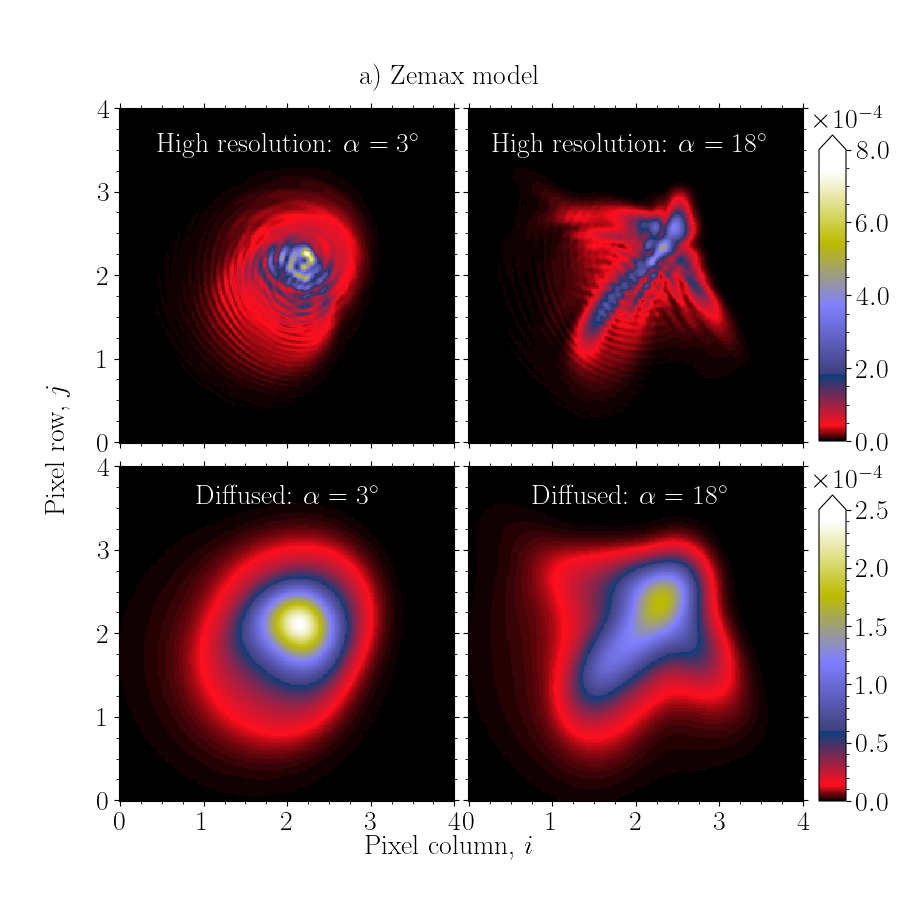

In [15]:
# Plot figure
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(9,9))
fig.subplots_adjust(hspace=0.07, wspace=0)

# Create plots
for i, psf, axes in zip(range(4), psfZemax, ax.flat):
    # Rotate psf
    angles = [180, 90, 0, 270]
    rotate = angles[int(ccdCode)-1]
    psf_rot = scipy.ndimage.rotate(psf, rotate)
    if i in (0, 1):
        im0 = axes.imshow(psf_rot, cmap=cm, vmin=0, vmax=vmax0, interpolation='nearest', origin='lower')
    elif i in (2, 3):
        im1 = axes.imshow(psf_rot, cmap=cm, vmin=0, vmax=vmax1, interpolation='nearest', origin='lower')

    # Settings
    axes.set_xticks(sub2pix_z)
    axes.set_yticks(sub2pix_z)
    axes.set_xticklabels(ticks)
    axes.set_yticklabels(ticks)

# Upper Colorbar
cbarax = fig.add_axes([0.91, 0.51, 0.03, 0.34])
cbar0 = plt.colorbar(im0, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar0.ax.tick_params()
# Colorbar scientific notation
cbar0.formatter.set_powerlimits((0, 0))
locs = ut.moveColorbarExponent(x_offs=0.0, y_offs=1.15, dig=1, side='left')

# Lower Colorbar
cbarax = fig.add_axes([0.91, 0.11, 0.03, 0.34])
cbar1 = plt.colorbar(im1, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar1.ax.tick_params()
# Colorbar scientific notation
cbar1.formatter.set_powerlimits((0, 0))
locs = ut.moveColorbarExponent(x_offs=0.0, y_offs=1.15, dig=1, side='left')

# Set all text
fig.suptitle("a) Zemax model", y=0.93, fontsize=20)
fig.text(0.5, 0.05, r'Pixel column, $i$', ha='center')
fig.text(0.05, 0.5, r'Pixel row, $j$', va='center', rotation='vertical')
fig.text(0.32, 0.83, r'High resolution: $\alpha=3^{\circ}$',     ha='center', color='white')
fig.text(0.70, 0.83, r'High resolution: $\alpha=18^{\circ}$',    ha='center', color='white')
fig.text(0.32, 0.44, r'Diffused: $\alpha=3^{\circ}$',  ha='center', color='white')
fig.text(0.70, 0.44, r'Diffused: $\alpha=18^{\circ}$', ha='center', color='white');

# Save figure
fig.savefig('psfZemax.png', bbox_inches='tight', dpi=200)

### Analytic non-Gaussian PSF

In [ ]:
# Coordinate corresponding to (-2.5, -2.5) in Carstens plot
ccdCode = "1"
xFPdeg = x1 + 5 * 0
yFPdeg = x1 + 5 * 3
xFPmm = xFPdeg * deg2mm
yFPmm = yFPdeg * deg2mm
xCCD = xFPdeg * deg2pix
yCCD = yFPdeg * deg2pix 

# Initialise PlatoSim
outputFileName = "output_AnalyticPSF_lowAlpha"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Run simulation
sim["PSF/Model"] = "AnalyticNonGaussian"
runsim(sim, ccdCode, xCCD, yCCD)

In [16]:
# Coordinate corresponding to (-2.5, -2.5) in Carstens plot
ccdCode = "1"
xFPdeg = x1 + 5 * 2
yFPdeg = x1 + 5 * 1
xFPmm = xFPdeg * deg2mm
yFPmm = yFPdeg * deg2mm
xCCD = xFPdeg * deg2pix
yCCD = yFPdeg * deg2pix 

# Initialise PlatoSim
outputFileName = "output_AnalyticPSF_highAlpha"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Run simulation
sim["PSF/Model"] = "AnalyticNonGaussian"
runsim(sim, ccdCode, xCCD, yCCD)


2023-02-07 10:48:46 WARNING Sky::zodiacalFlux(): No data for (alpha, delta) = (76.447511, -64.750476)
2023-02-07 10:48:46 WARNING Simulation: no information about detected stars to write to HDF5
2023-02-07 10:48:46 WARNING Camera: No star positions to write to HDF5 file.



In [17]:
# Load high resolution and diffused PSFs
f0 = h5py.File(f'{os.getcwd()}/output_AnalyticPSF_lowAlpha.hdf5', 'r')
psf0a = np.array(f0["PSF/highResPSF"] )[2*res_a:6*res_a, 2*res_a:6*res_a]  # We only want the inner 4 x 4 pixels
psf0d = np.array(f0["PSF/diffusedPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a]

f1 = h5py.File(f'{os.getcwd()}/output_AnalyticPSF_highAlpha.hdf5', 'r')
psf1a = np.array(f1["PSF/highResPSF"] )[2*res_a:6*res_a, 2*res_a:6*res_a]  
psf1d = np.array(f1["PSF/diffusedPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a]

# Combine for plot
psfAnalytic = [psf0a, psf1a, psf0d, psf1d]

# Normalize high-res and diffused PSFs w.r.t. each other, respectuvely
vmax0 = np.max(psf0a)
vmax1 = np.max(psf0d)

<IPython.core.display.Javascript object>


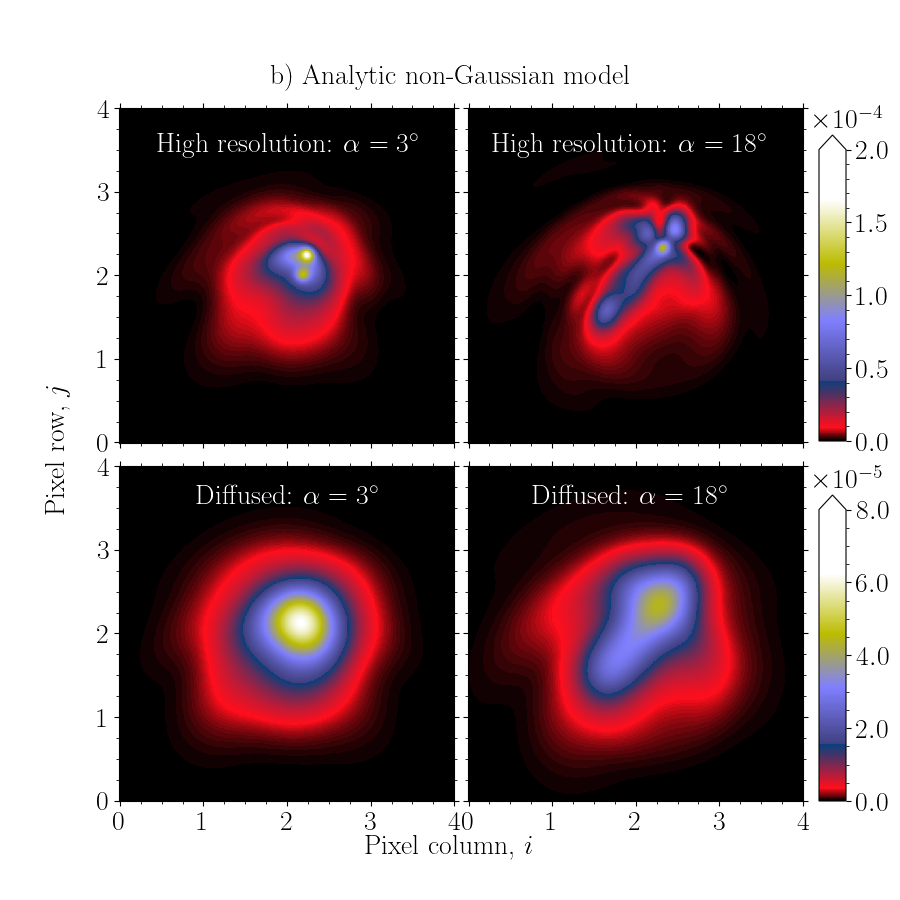

In [21]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(9,9))
fig.subplots_adjust(hspace=0.07, wspace=0)

# Create plots
for i, psf, axes in zip(range(4), psfAnalytic, ax.flat):
    # Rotate psf
    angles = [180, 90, 0, 270]
    rotate = angles[int(ccdCode)-1]
    psf_rot = scipy.ndimage.rotate(psf, rotate)
    
    if i in (0, 1):
        im0 = axes.imshow(psf_rot, cmap=cm, vmin=0, vmax=vmax0, interpolation='nearest', origin='lower')
    elif i in (2, 3):
        im1 = axes.imshow(psf_rot, cmap=cm, vmin=0, vmax=vmax1, interpolation='nearest', origin='lower')

    # Settings
    axes.set_xticks(sub2pix_a)
    axes.set_yticks(sub2pix_a)
    axes.set_xticklabels(ticks)
    axes.set_yticklabels(ticks)

# Upper Colorbar
cbarax = fig.add_axes([0.91, 0.51, 0.03, 0.34])
cbar0 = plt.colorbar(im0, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar0.ax.tick_params()
# Colorbar scientific notation
cbar0.formatter.set_powerlimits((0, 0))
locs = ut.moveColorbarExponent(x_offs=0.0, y_offs=1.15, dig=1, side='left')

# Lower Colorbar
cbarax = fig.add_axes([0.91, 0.11, 0.03, 0.34])
cbar1 = plt.colorbar(im1, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar1.ax.tick_params()
# Colorbar scientific notation
cbar1.formatter.set_powerlimits((0, 0))
locs = ut.moveColorbarExponent(x_offs=0.0, y_offs=1.15, dig=1, side='left')

# Set all text
fig.suptitle("b) Analytic non-Gaussian model", y=0.93, fontsize=20)
fig.text(0.5, 0.05,  r'Pixel column, $i$', ha='center')
fig.text(0.05, 0.5,  r'Pixel row, $j$', va='center', rotation='vertical')
fig.text(0.32, 0.83, r'High resolution: $\alpha=3^{\circ}$',     ha='center', color='white')
fig.text(0.70, 0.83, r'High resolution: $\alpha=18^{\circ}$',    ha='center', color='white')
fig.text(0.32, 0.44, r'Diffused: $\alpha=3^{\circ}$',  ha='center', color='white')
fig.text(0.70, 0.44, r'Diffused: $\alpha=18^{\circ}$', ha='center', color='white');

# Save figure
fig.savefig('psfAnalytic.png', bbox_inches='tight', dpi=200)

### Compared Zemax and Analytic non-Gaussian PSFs

### Full FP

In [13]:
# Matrix to calculate the PSFs
xFP = np.array([  0.0,   0.0, -7.5, -2.5, 2.5, 7.5,  0.0,  0.0,
                  0.0, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5,  0.0,
                -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5,
                -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5,
                -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5,
                -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5,
                  0.0, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5,  0.0,
                  0.0,   0.0, -7.5, -2.5, 2.5, 7.5,  0.0,  0.0])
yFP = np.array([  0.0,   0.0,  17.5,  17.5,  17.5,  17.5,   0.0,   0.0,
                  0.0,  12.5,  12.5,  12.5,  12.5,  12.5,  12.5,   0.0,
                  7.5,   7.5,   7.5,   7.5,   7.5,   7.5,   7.5,   7.5,
                  2.5,   2.5,   2.5,   2.5,   2.5,   2.5,   2.5,   2.5,
                 -2.5,  -2.5,  -2.5,  -2.5,  -2.5,  -2.5,  -2.5,  -2.5,
                 -7.5,  -7.5,  -7.5,  -7.5,  -7.5,  -7.5,  -7.5,  -7.5,
                  0.0, -12.5, -12.5, -12.5, -12.5, -12.5, -12.5,   0.0,
                  0.0,   0.0, -17.5, -17.5, -17.5, -17.5,   0.0,   0.0])
alpha = np.sqrt(xFP**2 + yFP**2)
inrot = np.rad2deg(np.arctan(yFP/xFP))
n = len(alpha)

/tmp/ipykernel_267117/3693641839.py:19: RuntimeWarning: invalid value encountered in divide
  inrot = np.rad2deg(np.arctan(yFP/xFP))


In [20]:
i = 10
ccdCode = "1"
deg2mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(1), focalLength)[0]
xFP_i = xFP[i] * deg2mm
yFP_i = yFP[i] * deg2mm

In [21]:
# Initialise PlatoSim
outputFileName = "output_AnalyticPSFfullFP_test"
sim = Simulation(outputFileName, outputDir=os.getcwd())
pixelSize     = sim["CCD/PixelSize"]
ccdZeroPointX = sim['CCDPositions/OriginOffsetX'][int(ccdCode)]
ccdZeroPointY = sim['CCDPositions/OriginOffsetY'][int(ccdCode)]
CCDangle      = np.deg2rad(sim['CCDPositions/Orientation'][int(ccdCode)])

In [23]:
# From focal plane coordinates to CCD coordinates
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP_i, yFP_i, pixelSize, ccdZeroPointX, ccdZeroPointY, CCDangle)
xCCD, yCCD

In [25]:
# Run simulation
sim["PSF/Model"] = "AnalyticNonGaussian"
runsim(sim, ccdCode, xCCD, yCCD)


2023-02-08 16:56:48 WARNING Simulation: no information about detected stars to write to HDF5
2023-02-08 16:56:48 WARNING Camera: No star positions to write to HDF5 file.



<IPython.core.display.Javascript object>


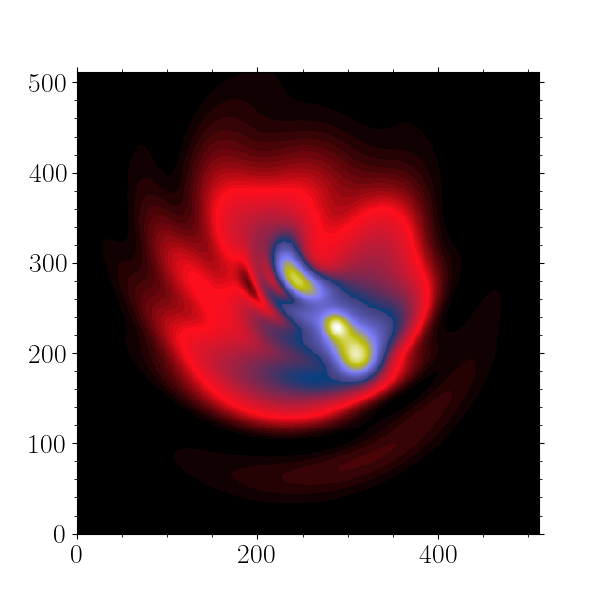

180


In [28]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(6,6))
fig.subplots_adjust(hspace=0.02, wspace=0)
# Load correct PSF
f   = h5py.File(f'{os.getcwd()}/{outputFileName}.hdf5', 'r')
psf = np.array(f["PSF/highResPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a] 
# Rotate psf
angles = [180, 90, 0, 270]
# angles = [270, 180, 270, 0]
rotate = angles[int(ccdCode)-1]
psf_rot = scipy.ndimage.rotate(psf, rotate)
# Plot PSF
im = ax.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
print(rotate)

In [19]:


# Run simulation
sim.run(removeOutputFile=True)

# Plot Zemax high res PSFs
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(6,6))
fig.subplots_adjust(hspace=0.02, wspace=0)
# Load correct PSF
string = "output_AnalyticPSFfullFP_test"
f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
psf = np.array(f["PSF/highResPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a] 
# Plot PSF
im = ax.imshow(psf, cmap="gnuplot2", interpolation='nearest', origin='lower')

NameError: name 'ccdZeroPointX' is not defined

In [ ]:
# From focal plane coordinates to CCD coordinates
# xFP_rad = np.deg2rad(-12.5)
# yFP_rad = np.deg2rad(-12.5)
# xFP = focalLength * np.tan(xFP_rad)
# yFP = focalLength * np.tan(yFP_rad)
# xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, 
#                                              pixelSize=sim["CCD/PixelSize"], 
#                                              ccdZeroPointX=0, ccdZeroPointY=0, 
#                                              CCDangle=ang)

In [ ]:
# Loop over each simulation
for i in tqdm(range(n), bar_format=ut.tqdm_bar_format()):

    # Select values
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    xFP_i   = xFP[i]
    yFP_i   = yFP[i]
    
    # Don't simulate empty spots
    if alpha_i == 0:
        pass
    else:
        
        # From alpha to focal plane coordinates
        if i in (4,5,6,7,12,13,14,15,20,21,22,23,28,29,30,31):
            ccdAngle = 0
        elif i in (0,1,2,3,8,9,10,11,16,17,18,19,24,25,26,27):
            ccdAngle = 90
            inrot_i  = 90 + inrot_i
        elif i in (32,33,34,35,40,41,42,43,48,49,50,51,56,57,58,59):
            ccdAngle = 180
            inrot_i  = 180 + inrot_i
        elif i in (36,37,38,39,44,45,46,47,52,53,54,55,60,61,62,63):
            ccdAngle = 270
            inrot_i  = 270 + inrot_i
            
        # Initialise PlatoSim
        outputFileName = "output_AnalyticPSFfullFP_num" + f"{i}".zfill(2)
        sim = Simulation(outputFileName, outputDir=os.getcwd())

        focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000
        xFP_pos, yFP_pos = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha_i), focalLength, 
                                                                              inPlaneRotation=np.deg2rad(inrot_i))

        # From focal plane coordinates to CCD coordinates
        pixelSize  = sim["CCD/PixelSize"]
        xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP_pos, yFP_pos, pixelSize, 
                                                     ccdZeroPointX=0, ccdZeroPointY=0, 
                                                     CCDangle=ccdAngle)

        # Observation
        sim["ObservingParameters/NumExposures"] = 1

        # Subfield (note y here is row and x is column)
        xzero = sim["SubField/ZeroPointRow"]    = int(yCCD)
        yzero = sim["SubField/ZeroPointColumn"] = int(xCCD)
        xsub  = sim["SubField/NumColumns"]      = 8
        ysub  = sim["SubField/NumRows"]         = 8

        # Camera
        sim["Camera/IncludePointLikeGhosts"] = False
    
        # PSF
        sim["PSF/Model"] = "AnalyticNonGaussian"
        sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

        # Control HDF5
        sim["ControlHDF5Content/WriteStarPositions"]     = True
        sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
        sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

        # Create star catalogue (path to starcat is automatically by function)
        xpos = np.array([int(xsub/2.) + xzero])
        ypos = np.array([int(ysub/2.) + yzero])
        mag  = np.array([10.0])
        ID   = np.array([1])
        starcat = f"{os.getcwd()}/starcat.txt"
        sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

        # Run simulation
        sim.run(removeOutputFile=True)

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Analytic High Resolution PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    xFP_i = xFP[i]
    yFP_i = yFP[i]
    
    # Don't simulate empty spots
    if xFP_i == 0:
        axes.axis('off')
    else:
        
        # Load correct PSF
        string = "output_AnalyticPSFfullFP_num" + f"{i}".zfill(2)
        f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
        psf = np.array(f["PSF/highResPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a]
    
        # Plot PSF
        im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
        # Setting
        text = f"{xFP_i:.1f}" + r"$^{\circ}$, " + f"{yFP_i:.1f}" + r"$^{\circ}$"
        axes.text(0.5, 0.9, text, color='white', fontsize=13, 
                  horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])

# Save figure
fig.savefig('psfAnalyticHigResFullFP.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# Loop over each simulation
for i in tqdm(range(n), bar_format=ut.tqdm_bar_format()):

    # Select values
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Don't simulate empty spots
    if alpha_i == 0:
        pass
    else: 
        # Initialise PlatoSim
        outputFileName = ("output_ZemaxPSFfullFP_num" + f"{i}".zfill(2) + 
                          "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i))
        sim = Simulation(outputFileName, outputDir=os.getcwd())

        # From alpha to focal plane coordinates
        if i in (0,1,2,3,8,9,10,11,16,17,18,19):
            inrot_i = 180 - inrot_i
        focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000
        xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha_i), focalLength, 
                                                                      inPlaneRotation=np.deg2rad(inrot_i))

        # From focal plane coordinates to CCD coordinates
        pixelSize  = sim["CCD/PixelSize"]
        xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                                 ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)

        # Observation
        sim["ObservingParameters/NumExposures"] = 1

        # Subfield (note y here is row and x is column)
        xzero = sim["SubField/ZeroPointRow"]    = int(yCCD)
        yzero = sim["SubField/ZeroPointColumn"] = int(xCCD)
        xsub  = sim["SubField/NumColumns"]      = 8
        ysub  = sim["SubField/NumRows"]         = 8

        # Camera
        sim["Camera/IncludePointLikeGhosts"] = False
    
        # PSF
        sim["PSF/Model"] = "MappedFromFile"
        sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

        # Control HDF5
        sim["ControlHDF5Content/WriteStarPositions"]     = True
        sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
        sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

        # Create star catalogue (path to starcat is automatically by function)
        xpos = np.array([int(xsub/2.) + xzero])
        ypos = np.array([int(ysub/2.) + yzero])
        mag  = np.array([10.0])
        ID   = np.array([1])
        starcat = f"{os.getcwd()}/starcat.txt"
        sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

        # Run simulation
        sim.run(removeOutputFile=True)

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Zemax High Resolution PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Don't simulate empty spots
    if alpha_i == 0:
        pass
    else: 
        string = "output_ZemaxPSFfullFP_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
        f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
        psf = np.array(f["PSF/rotatedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
    
        # Plot PSF
        im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
        # Setting
        text = f"{alpha_i:.1f}" + r"$^{\circ}$, " + f"{inrot_i:.1f}" + r"$^{\circ}$"
        axes.text(0.5, 0.9, text, color='white', fontsize=13, 
                  horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])

# Save figure
fig.savefig('psfZemaxHigResFullFP.pdf', bbox_inches='tight', dpi=200)

### Quadrant of FP

In [ ]:
# Matrix to calculate the PSFs
alpha = [14.6, 14.7, 15.2, 15.9, 16.8, 17.9, 19.2, 20.6,
         12.5, 12.7, 13.2, 14.0, 15.0, 16.3, 17.7, 19.2,
         10.4, 10.6, 11.2, 12.1, 13.3, 14.7, 16.3, 17.9,
          8.3,  8.6,  9.3, 10.4, 11.8, 13.3, 15.0, 16.8,
          6.2,  6.6,  7.5,  8.8, 10.4, 12.1, 14.0, 15.9,
          4.2,  4.7,  5.9,  7.5,  9.3, 11.2, 13.2, 15.2, 
          2.1,  2.9,  4.7,  6.6,  8.6, 10.6, 12.7, 14.7,
          0.0,  2.1,  4.2,  6.2,  8.3, 10.4, 12.5, 14.6]
inrot = [90.0, 81.9, 74.1, 66.8, 60.3, 54.5, 49.4, 45.0,
         90.0, 80.5, 71.6, 63.4, 56.3, 50.2, 45.0, 40.6,
         90.0, 78.7, 68.2, 59.0, 51.3, 45.0, 39.8, 35.5,
         90.0, 76.0, 63.4, 53.1, 45.0, 38.7, 33.7, 29.7,
         90.0, 71.6, 56.3, 45.0, 36.9, 31.0, 26.6, 23.2,
         90.0, 63.4, 45.0, 33.7, 26.6, 21.8, 18.4, 15.9,
         90.0, 45.0, 26.0, 18.4, 14.0, 11.3,  9.5,  8.1,
          0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0, 0.0]
n = len(alpha)

In [ ]:
# Loop over each simulation
for i in tqdm(range(n), bar_format=ut.tqdm_bar_format()):

    # Select values
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Initialise PlatoSim
    outputFileName = ("output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i))
    sim = Simulation(outputFileName, outputDir=os.getcwd())

    # From alpha to focal plane coordinates
    focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000
    xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha_i), focalLength, 
                                                                  inPlaneRotation=np.deg2rad(inrot_i))

    # From focal plane coordinates to CCD coordinates
    pixelSize  = sim["CCD/PixelSize"]
    xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                                 ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)

    # Observation
    sim["ObservingParameters/NumExposures"] = 1

    # Subfield (note y here is row and x is column)
    xzero = sim["SubField/ZeroPointRow"]    = int(yCCD)
    yzero = sim["SubField/ZeroPointColumn"] = int(xCCD)
    xsub  = sim["SubField/NumColumns"]      = 8
    ysub  = sim["SubField/NumRows"]         = 8

    # Camera
    sim["Camera/IncludePointLikeGhosts"] = False
    
    # PSF
    sim["PSF/Model"] = "MappedFromFile"
    sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

    # Control HDF5
    sim["ControlHDF5Content/WriteStarPositions"]     = True
    sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
    sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

    # Create star catalogue (path to starcat is automatically by function)
    xpos = np.array([int(xsub/2.) + xzero])
    ypos = np.array([int(ysub/2.) + yzero])
    mag  = np.array([10.0])
    ID   = np.array([1])
    starcat = f"{os.getcwd()}/starcat.txt"
    sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

    # Run simulation
    sim.run(removeOutputFile=True)

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Zemax High Resolution PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    string = "output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
    psf = np.array(f["PSF/rotatedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
    
    # Plot PSF
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
    # Setting
    text = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
    axes.text(0.5, 0.9, text, color='white', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
    
# Save figure
fig.savefig('psfZemaxHigResFP.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Zemax High Resolution Diffused PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    string = "output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
    psf = np.array(f["PSF/diffusedPSF"])[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
    
    # Plot PSF
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
    # Settings
    text = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
    axes.text(0.5, 0.9, text, color='white', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
# Save figure
fig.savefig('psfZemaxDiffusedFP.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# Loop over each simulation
for i in tqdm(range(n), bar_format=ut.tqdm_bar_format()):

    # Select values
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Initialise PlatoSim
    outputFileName = ("output_AnalyticPSF_num" + f"{i}".zfill(2) + 
                      "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i))
    sim = Simulation(outputFileName, outputDir=os.getcwd())

    # From alpha to focal plane coordinates
    focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000
    xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha_i), focalLength, 
                                                                  inPlaneRotation=np.deg2rad(inrot_i))

    # From focal plane coordinates to CCD coordinates
    pixelSize  = sim["CCD/PixelSize"]
    xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)

    # Observation
    sim["ObservingParameters/NumExposures"] = 1

    # Subfield (note y here is row and x is column)
    xzero = sim["SubField/ZeroPointRow"]    = int(yCCD)
    yzero = sim["SubField/ZeroPointColumn"] = int(xCCD)
    xsub  = sim["SubField/NumColumns"]      = 8
    ysub  = sim["SubField/NumRows"]         = 8

    # Camera
    sim["Camera/IncludePointLikeGhosts"] = False
    
    # PSF
    sim["PSF/Model"] = "AnalyticNonGaussian"
    sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

    # Control HDF5
    sim["ControlHDF5Content/WriteStarPositions"]     = True
    sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
    sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

    # Create star catalogue (path to starcat is automatically by function)
    xpos = np.array([int(xsub/2.) + xzero])
    ypos = np.array([int(ysub/2.) + yzero])
    mag  = np.array([10.0])
    ID   = np.array([1])
    starcat = f"{os.getcwd()}/starcat_AnalyticPSF_matrix.txt"
    sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

    # Run simulation
    sim.run(removeOutputFile=True)

In [ ]:
# Plot large view of PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Analytic non-Gaussian High Resolution PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    string = "output_AnalyticPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
    psf = np.array(f["PSF/highResPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a]  # We only want the inner 4 x 4 pixels
    
    # Plot PSF
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
    # Settings
    text = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
    axes.text(0.5, 0.9, text, color='white', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
# Save figure
fig.savefig('psfAnalyticHigResFP.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# Plot large view of PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Analytic non-Gaussian High Resolution Diffused PSFs", y=0.9, fontsize=20)

# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    string = "output_AnalyticPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f   = h5py.File(f'{os.getcwd()}/{string}.hdf5', 'r')
    psf = np.array(f["PSF/diffusedPSF"])[2*res_a:6*res_a, 2*res_a:6*res_a]  # We only want the inner 4 x 4 pixels
    
    # Plot PSF
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')
    
    # Settings
    text = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
    axes.text(0.5, 0.9, text, color='white', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
# Save figure
fig.savefig('psfAnalyticDiffusedFP.pdf', bbox_inches='tight', dpi=200)

### Residual diffused PSFs

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Residuals between non-diffused PSFs: Analytic non-Gaussian - Zemax PSFs", y=0.9, fontsize=20)


# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Zemax
    string_z = "output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f_z      = h5py.File(f'{os.getcwd()}/{string_z}.hdf5', 'r')
    psf_z    = np.array(f_z["PSF/rotatedPSF"]) #[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
        
    # Analytic non-Gaussian
    string_a = "output_AnalyticPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f_a      = h5py.File(f'{os.getcwd()}/{string_a}.hdf5', 'r')
    psf_a    = np.array(f_a["PSF/highResPSF"]) #[2*res_a:6*res_a, 2*res_a:6*res_a]  # We only want the inner 4
    
    # Interpolate to same grid
    n_z = len(psf_z)
    n_a = len(psf_a)
    xx_a = yy_a = np.arange(n_a)
    xx_z = yy_z = xx_a[::2]
    interp = interp2d(xx_a, yy_a, psf_a, kind="cubic")
    psf_a = interp(xx_z, yy_z) * 4 # 4 is to preserve the sum to be 1

    # Residuals
    res = psf_a - psf_z
    res_zoom = res[2*res_z:6*res_z, 2*res_z:6*res_z]
    
    # Plot PSF
    im = axes.imshow(res_zoom, norm=colors.CenteredNorm(), cmap="PuOr", interpolation='nearest', origin='lower')
    
    # Settings
    text1 = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
#     text2 = f"{res.min()*100:.2f}\%, {res.max()*100:.2f}\%"
    text2 = f"{res.min()*1e5:.1f}" + r"\textperthousand" + ", " + f"{res.max()*1e5:.1f}" + r"\textperthousand"

    axes.text(0.5, 0.9, text1, color='black', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.text(0.5, 0.1, text2, color='black', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
# Save figure
fig.savefig('psfResidualsHighResFP.pdf', bbox_inches='tight', dpi=200)

In [ ]:
# Plot Zemax high res PSFs
fig, ax = plt.subplots(8, 8, sharex=True, sharey=True, figsize=(14,14))
fig.subplots_adjust(hspace=0.02, wspace=0)
fig.suptitle("Residuals between Diffused PSFs: Analytic non-Gaussian - Zemax", y=0.9, fontsize=20)


# Create plots
for i, axes in zip(range(n), ax.flat):

    # Load high resolution and diffused PSFs
    alpha_i = alpha[i]
    inrot_i = inrot[i]
    
    # Zemax
    string_z = "output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f_z      = h5py.File(f'{os.getcwd()}/{string_z}.hdf5', 'r')
    psf_z    = np.array(f_z["PSF/diffusedPSF"]) #[2*res_z:6*res_z, 2*res_z:6*res_z]  # We only want the inner 4 x 4 pixels
        
    # Analytic non-Gaussian
    string_a = "output_AnalyticPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i)
    f_a      = h5py.File(f'{os.getcwd()}/{string_a}.hdf5', 'r')
    psf_a    = np.array(f_a["PSF/diffusedPSF"]) #[2*res_a:6*res_a, 2*res_a:6*res_a]  # We only want the inner 4
    
    flux0 = psf_a.sum()
    
    # Interpolate to same grid
    n_z = len(psf_z)
    n_a = len(psf_a)
    xx_a = yy_a = np.arange(n_a)
    xx_z = yy_z = xx_a[::2]
    interp = interp2d(xx_a, yy_a, psf_a, kind="cubic")
    psf_a = interp(xx_z, yy_z) * 4 # 4 is to preserve the sum to be 1
    
    # Residuals
    res = psf_a - psf_z
    res_zoom = res[2*res_z:6*res_z, 2*res_z:6*res_z]
    
    # Plot PSF
    im = axes.imshow(res, norm=colors.CenteredNorm(), cmap="BrBG", interpolation='nearest', origin='lower')
    
    # Settings
    text1 = f"{alpha_i}" + r"$^{\circ}$, " + f"{inrot_i}" + r"$^{\circ}$"
#     text2 = f"{res.min()*1e5:.1f}"+ r"$\text{\textperthousand}$, " + f"{res.max()*1e5:.1f}\%"
    text2 = f"{res.min()*1e5:.1f}" + r"\textperthousand" + ", " + f"{res.max()*1e5:.1f}" + r"\textperthousand"

    axes.text(0.5, 0.9, text1, color='black', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    axes.text(0.5, 0.1, text2, color='black', fontsize=13, 
              horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)
    
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_xticklabels([])
    axes.set_yticklabels([])
    
# Save figure
fig.savefig('psfResidualsDiffusedFP.pdf', bbox_inches='tight', dpi=200)